#Projet de ML01 A25  : Applications d'algorithmes de Machine Learning sur l'efficience énergétique de batîments

Lefbvre Gabin - Finta Lysandre - Noyon Auguste - Jariri Sarah

Ce projet a pour objectif d’appliquer les algorithmes et concepts abordés en cours et en travaux dirigés de ML01 à l’étude d’une base de données réelle.

La base de données utilisée dans le cadre de ce projet concerne la performance énergétique de bâtiments, et plus précisément l’estimation de la charge de chauffage à partir de différentes caractéristiques de conception architecturale et géométrique. Cette base de données, intitulée Energy Efficiency Dataset, est issue de la plateforme Kaggle, où elle est librement accessible à l'adresse suivante : https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset/data

L’objectif principal est de comprendre comment les paramètres physiques et géométriques d’un bâtiment influencent sa consommation énergétique, et d’évaluer dans quelle mesure des méthodes de Machine Learning permettent de prédire le niveau de charge de chauffage ou de classer les bâtiments selon leur performance énergétique.

Ce projet est structuré en plusieurs parties permettant de répondre progressivement à la problématique définie. Le plan du notebook est présenté ci-dessous :

**Plan du projet**

- Présentation de la base de données

- Analyse de la corrélation de nos données

- Élaboration de la problématique

- Sélection des variables pertinentes

    - Regression logistique LASSO

    - Recherches sur l'élagage des arbres

- Mise en place et comparaison des classifieurs :

    - Bayes naïf  

    - QDA

    - LDA

    - Perceptron
    
    - Régression logistique

    - Classifieur euclidien

    - KNN

    - Random Forest

- Comparaison des modèles par validation croisée

- Positionnement au regard de l'ingénieurie soutenable (IS)

- Choix d'un modèle

- Conclusion


**1. Présentation de la base de données**

La base de données utilisée a été constituée par Angeliki Xifara et Athanasios Tsanas. Elle regroupe les caractéristiques énergétiques et architecturales de 768 bâtiments.

Initialement, cette base de données comportait deux variables cibles : la charge de chauffage et la charge de refroidissement. Dans le cadre de ce projet, nous avons fait le choix de nous concentrer uniquement sur la charge de chauffage, afin de simplifier l’analyse et de nous focaliser sur l’évaluation de la performance énergétique liée aux besoins de chauffage.

La base de données comprend huit variables descriptives, dont six variables numériques et deux variables catégorielles, décrivant les propriétés géométriques et énergétiques des bâtiments étudiés.

Les tableaux présentés ci-dessous détaillent l’ensemble de ces variables, ainsi que leur nature.

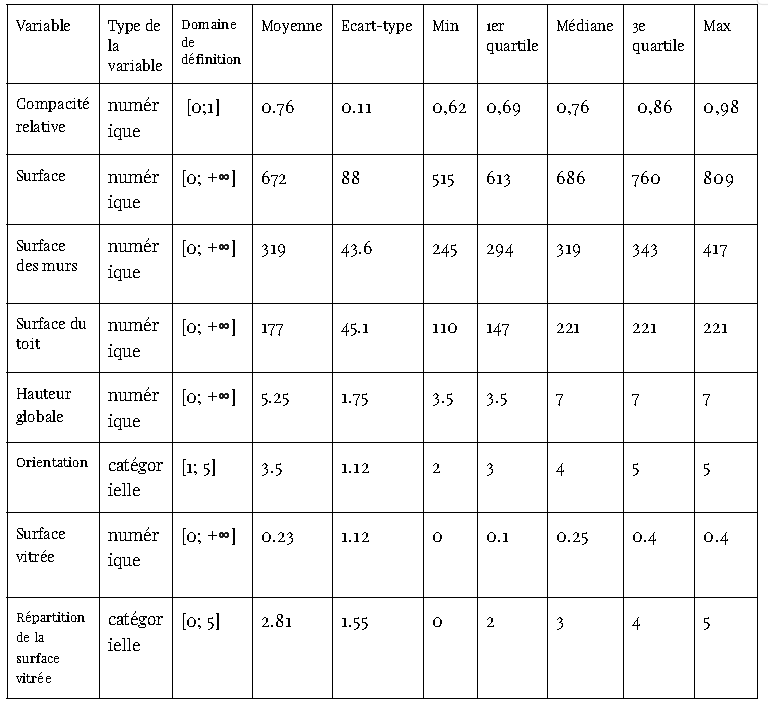

* Variable à prédire


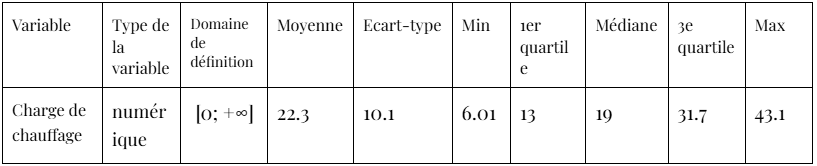

Nous allons maintenant importer les données afin de répresenter nos différentes variables par des statistiques descriptives.

In [ ]:
# @title Initialisation de la base de données et des librairies
#import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
import scipy.stats as stats

#import des données
try:
  data = pd.read_csv("ENB2012_data.csv")
except:
  data = pd.read_excel("ENB2012_data.xlsx")

#on renomme les colonnes avec leurs noms
data.columns = ['X1 : Compacité_relative', 'X2 : Surface', 'X3 : Surface_des_murs', 'X4 : Surface_du_toit', 'X5 : Hauteur_globale',
                'X6 : Orientation', 'X7 : Surface_vitrée', 'X8 : Répartition_de_la_surface_vitrée', 'Y1 : Charge_de_chauffage', 'Y2 : Charge_de_refroidissement']

# Initialisation des trackers carbone

In [ ]:
!pip install codecarbon

In [ ]:
from codecarbon import EmissionsTracker

tracker_LR = EmissionsTracker(project_name='Logistic Regression')
tracker_QDA = EmissionsTracker(project_name='QDA')
tracker_LDA = EmissionsTracker(project_name='LDA')
tracker_Perc = EmissionsTracker(project_name='Perceptron')
tracker_KNN = EmissionsTracker(project_name='KNN')
tracker_NC = EmissionsTracker(project_name='Nearest Centroid')
tracker_BN = EmissionsTracker(project_name='Bayes Naif')
tracker_DT = EmissionsTracker(project_name='Decision Tree')
tracker_RF = EmissionsTracker(project_name='Random Forest')

In [ ]:
# @title Tableau récapitulatif de toutes la base de données
#on renomme les colonnes avec leurs noms
data.columns = ['X1 : Compacité_relative', 'X2 : Surface', 'X3 : Surface_des_murs', 'X4 : Surface_du_toit', 'X5 : Hauteur_globale',
                'X6 : Orientation', 'X7 : Surface_vitrée', 'X8 : Répartition_de_la_surface_vitrée', 'Y1 : Charge_de_chauffage', 'Y2 : Charge_de_refroidissement']

#on affiche le tableau de toutes les données
data

,X1 : Compacité_relative,X2 : Surface,X3 : Surface_des_murs,X4 : Surface_du_toit,X5 : Hauteur_globale,X6 : Orientation,X7 : Surface_vitrée,X8 : Répartition_de_la_surface_vitrée,Y1 : Charge_de_chauffage,Y2 : Charge_de_refroidissement
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5,16.48,16.61


In [ ]:
# @title Découpage des différentes classes de la variable à prédire
# on calcule les valeurs max, min et la portée de Y1
y1_min = data['Y1 : Charge_de_chauffage'].min()
y1_max = data['Y1 : Charge_de_chauffage'].max()
y1_range = y1_max - y1_min

# on définit les différentes classes
class_boundaries = [y1_min, y1_min + y1_range/4, y1_min + 2*y1_range/4, y1_min + 3*y1_range/4, y1_max]

# on crée la nouvelle colonne Classe_Y1
data['Classe_Y1'] = pd.cut(data['Y1 : Charge_de_chauffage'], bins=class_boundaries, labels=['Class 1', 'Class 2', 'Class 3', 'Class 4'], include_lowest=True)

# on enlève la colonne Y2
data = data.drop('Y2 : Charge_de_refroidissement', axis=1)

# nouveau dataframe
display(data.head())

,X1 : Compacité_relative,X2 : Surface,X3 : Surface_des_murs,X4 : Surface_du_toit,X5 : Hauteur_globale,X6 : Orientation,X7 : Surface_vitrée,X8 : Répartition_de_la_surface_vitrée,Y1 : Charge_de_chauffage,Classe_Y1
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,Class 2
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,Class 2
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,Class 2
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,Class 2
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,Class 2


**Choix de la variable à prédir et découpage des classes**

La base de donnée sur laquelle le travail a été effectué contient deux variables numériques à prédire, qui sont Y1 : Charge de chauffage et Y2 : Charge de refroidissement.

La charge de chauffage et de refroidissement étant fortement corrélées, car dépendantes des mêmes variables géométriques et thermiques du bâtiment, nous avons fait le choix de nous concentrer uniquement sur la prédiction de Y1. Ce choix permet de simplifier l'analyse et de comparer un plus grand nombre de classifieurs, sans perte significative d'information.

La variable cible Y1 étant continue, elle a été discrétisée en 4 classes en divisant uniformément son domaine de variation, de Y1min à Y1max, en intervalles de largeur égale. Ce découpage permet de structurer la variable cible en niveaux croissants de charge de chauffage, facilitant l'apprentissage et la comparaison des classifieurs, tout en évitant l'introduction de seuils empiriques dépendants de la distribution des données.

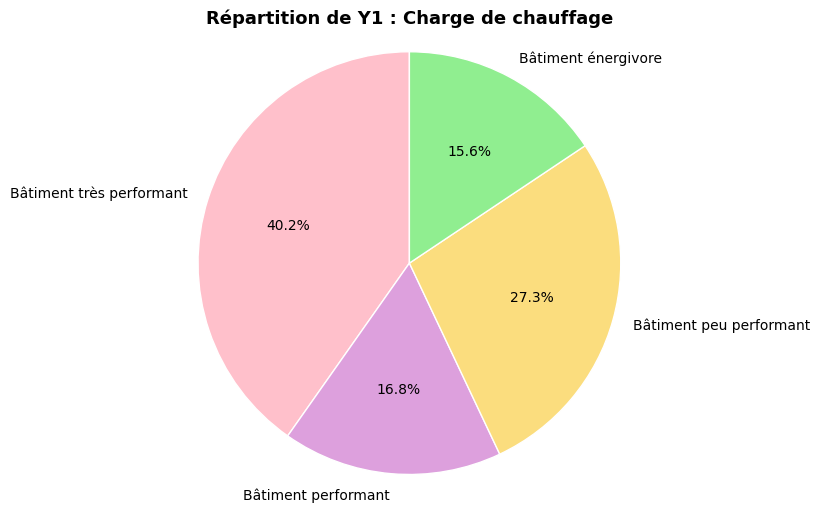

In [ ]:
# @title Graphique de proportion par classe Y1 sous forme de pieplot

import matplotlib.pyplot as plt

# colonne d'intérêt
class_column = 'Classe_Y1'

# mapping des anciennes classes vers les nouveaux noms
class_name_mapping = {
    'Class 1': 'Bâtiment très performant',
    'Class 2': 'Bâtiment performant',
    'Class 3': 'Bâtiment peu performant',
    'Class 4': 'Bâtiment énergivore'
}

# ordre d'affichage
class_order = list(class_name_mapping.values())

# création de la colonne Classe renommée
data['Classe'] = data[class_column].map(class_name_mapping)

# comptage des effectifs
class_counts = data['Classe'].value_counts().reindex(class_order, fill_value=0)

# couleurs
colors = ['#FFC0CB', '#DDA0DD', '#FBDD7E', '#ADD8E6']

# diagramme pieplot
plt.close('all')
plt.figure(figsize=(6, 6))

plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)

plt.title(
    "Répartition de Y1 : Charge de chauffage",
    fontsize=13,
    fontweight='bold'
)

plt.axis('equal')
plt.show()

# Nettoyage
data.drop(columns=['Classe'], inplace=True)


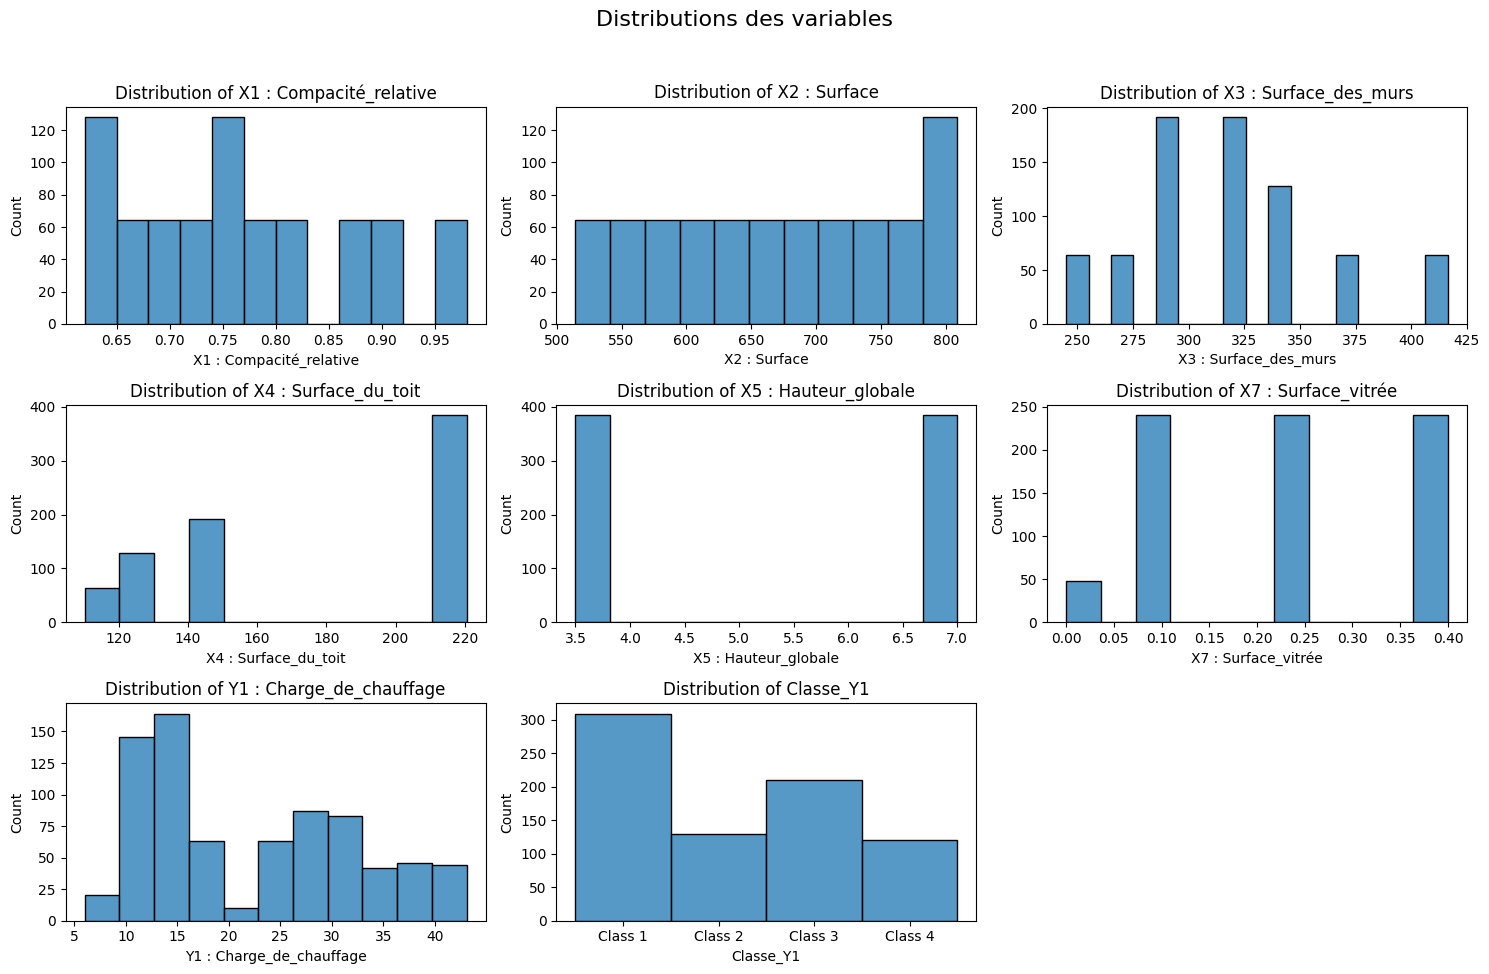

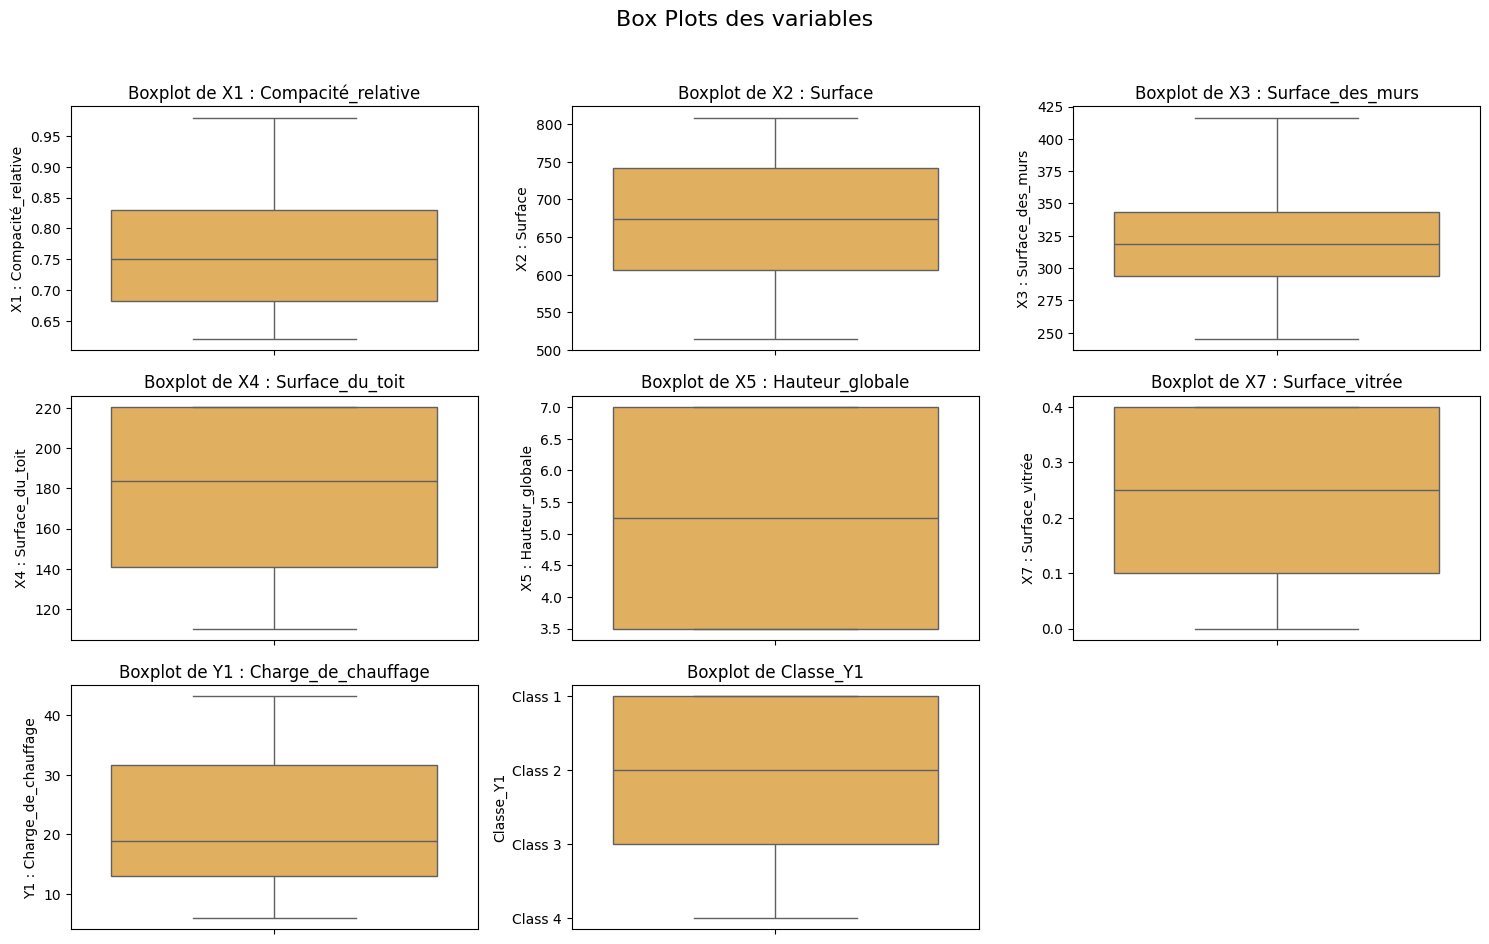

In [ ]:
# @title Histogrammes et Boxplots de chacune des variables
plt.figure(figsize=(15, 12))
plt.suptitle("Distributions des variables", y=1.02, fontsize=16)

columns_to_plot = [col for col in data.columns if col not in ['X6 : Orientation', 'X8 : Répartition_de_la_surface_vitrée']]

# histogrammes pour chaque variable
for i, column in enumerate(columns_to_plot):
    plt.subplot(4, 3, i+1)
    sns.histplot(data[column])
    plt.title(f'Distribution of {column}')
    plt.tight_layout()

plt.show()

# boxplots pour chaque variable
plt.figure(figsize=(15, 12))
plt.suptitle("Box Plots des variables", y=1.02, fontsize=16)

for i, column in enumerate(columns_to_plot):
    plt.subplot(4, 3, i+1)
    sns.boxplot(y=data[column], color="#f6b44b")
    plt.title(f'Boxplot de {column}')
    plt.tight_layout()

plt.show()

# Analyse de la distribution de nos données       
1. Compacité relative

Selon l'histogramme : distribution asymétrique, centrée environ autour de 0.75.
Selon le boxplot : faible dispersion, peu de valeurs extrêmes → la variable est homogène.

2. Surface

Selon l'histogramme : distribution uniforme entre 500 et  775 m², puis une augmentation des valeurs entre 775 et 825 m².
Selon le boxplot : plage de valeurs assez large, présence de valeurs extrêmes.

3. Surface des murs

Selon l'histogramme : distribution multimodale (plusieurs pics), légérement symétrique si on prend environ 325 comme axe de symétrie.
Selon le boxplot : dispersion moyenne, quelques valeurs extrêmes.

4. Surface du toit

Selon l'histogramme : distribution asymétrique forte, concentrée autour de 110-150 m² et 210-220 m².
Selon le boxplot : asymétrie, queue droite très forte.

5. Hauteur globale

Selon l'histogramme : distribution nette, deux valeurs dominantes à ~3.5 et ~7 m.
Selon le boxplot : très faible dispersion, deux groupes bien séparés.

6. Surface vitrée

Selon l'histogramme : 4 groupes de valeurs, un petit groupe entre 0 et 0.05 m², et trois groupes de tailles égales entre 0.075 et 0.1 m², entre 0.22 et 0.26 m² et entre 0.36 et 0.4 m² environ.
Selon le boxplot : faible dispersion, asymétrie : queue droite plus importante.

7. Charge de chauffage

Selon l'histogramme : distribution asymétrique, queue gauche plus importante.
Selon le boxplot : quelques valeurs extrêmes.

Nous avons également mis la répartition de nos classes.


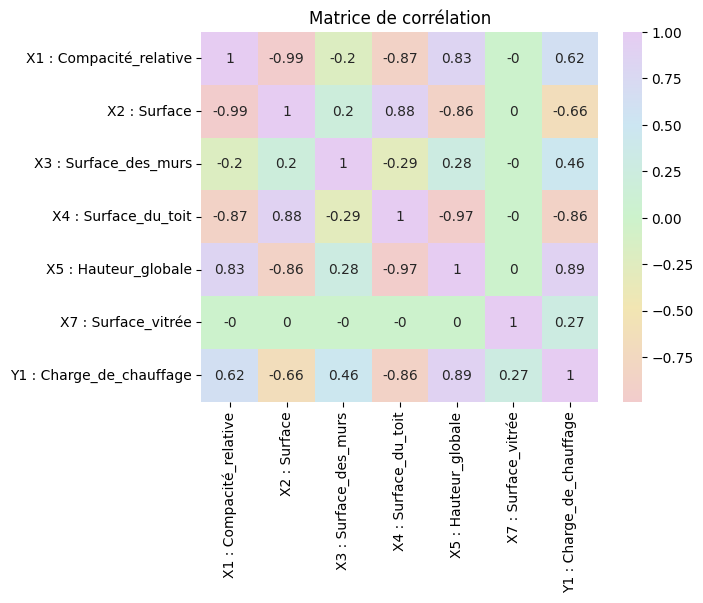

In [ ]:
# @title Matrice de corrélation entre les variables et la charge de chauffage
selected_columns = ['X1 : Compacité_relative', 'X2 : Surface', 'X3 : Surface_des_murs', 'X4 : Surface_du_toit', 'X5 : Hauteur_globale', 'X7 : Surface_vitrée', 'Y1 : Charge_de_chauffage']
data_selected = data[selected_columns]
correlation = data_selected.corr().round(2)
from matplotlib.colors import LinearSegmentedColormap
pastel_colors = [
    (0.95, 0.80, 0.80),
    (0.95, 0.90, 0.70),
    (0.80, 0.95, 0.80),
    (0.80, 0.90, 0.95),
    (0.90, 0.80, 0.95)
]

pastel_rainbow = LinearSegmentedColormap.from_list("pastel_rainbow", pastel_colors)

sns.heatmap(correlation, annot=True, cmap=pastel_rainbow)
plt.title('Matrice de corrélation')
plt.show()



# Analyse de la corrélation de nos données :

- On observe des corrélations très fortes (positives et négatives) entre certaines caractéristiques du bâtiment.

Variables les plus corrélés à la charge de chauffage :

- Hauteur_globale présente la corrélation positive la plus forte avec la charge de chauffage (r = 0.89)

- Surface_du_toit est fortement négativement corrélée à la charge de chauffage (r ≈ -0.86).

- Surface et compacité_relative sont également corrélées négativement à la charge de chauffage (r ≈ -0.66).

- Surface_des_murs a une corrélation modérée positive (r ≈ 0.46).
  

Variables faiblement corrélées avec la charge de chauffage :

- Orientation, surface_vitrée et répartition_de_la_surface_vitrée montrent des corrélations proches de zéro avec la charge de chauffage.

Conclusion :

- Les paramètres géométriques (hauteur, surface du toit, compacité) sont les principaux facteurs influençant les performances énergétiques.

- Les facteurs d’orientation et de vitrage jouent un rôle mineur dans ce cas.




#Élaboration de la problématique

Après investigation de la base de données Energy Efficiency, il apparaît que la consommation énergétique d’un bâtiment, et plus particulièrement la charge de chauffage, dépend de nombreuses caractéristiques architecturales et géométriques. La base de données met à disposition 8 variables explicatives, décrivant à la fois la forme globale du bâtiment et ses propriétés physiques.

La performance énergétique d’un bâtiment est généralement influencée par des paramètres géométriques, tels que :

- la compacité relative du bâtiment,

- la surface et l’orientation des murs,

- la surface du toit,

- la hauteur globale du bâtiment ;

- des paramètres liés aux ouvertures, incluant :

    - la surface vitrée,

    - la répartition des fenêtres selon leur orientation ;

    - des aspects de conception énergétique, qui conditionnent les pertes thermiques et les besoins en chauffage.

La charge de chauffage représente la quantité d’énergie nécessaire pour maintenir une température intérieure confortable lorsque les conditions climatiques extérieures sont défavorables. Une charge de chauffage élevée est généralement le signe d’un bâtiment peu performant sur le plan énergétique, ce qui engendre des coûts économiques importants ainsi qu’un impact environnemental accru.

Dans un contexte de transition énergétique et de réduction des émissions de gaz à effet de serre, l’amélioration de la performance énergétique des bâtiments constitue un enjeu majeur. Cependant, l’évaluation précise de cette performance repose souvent sur des méthodes de calcul complexes, des simulations thermiques coûteuses ou des audits énergétiques longs et parfois difficiles à mettre en œuvre à grande échelle.

Il est alors possible de constater que l’estimation de la performance énergétique d’un bâtiment, et notamment de sa charge de chauffage, peut s’avérer chronophage et technique, ce qui limite son accessibilité pour des études rapides ou des prises de décision préliminaires lors de la conception architecturale.

Il serait alors judicieux de se demander si l’apport de l’intelligence artificielle et des méthodes d’apprentissage automatique pourrait permettre d’améliorer la prédiction de la charge de chauffage à partir de caractéristiques simples du bâtiment, et ainsi faciliter l’évaluation de sa performance énergétique dès les premières phases de conception.

**PROBLÉMATIQUE**

Comment prédire le niveau de charge de chauffage d’un bâtiment à partir de ses caractéristiques  architecturales et géométriques ?

# Sélection des variables pertinentes

Le but de cette section est de sélectionner les variables susceptibles de prédire efficacement la charge de chauffage d’un bâtiment à l’aide d’algorithmes de Machine Learning.

Pour ce faire, nous allons utiliser deux méthodes et comparer leurs résultats :

1. Régression logistique avec régularisation LASSO
   La calibration des coefficients lors de la création d’un modèle de régression logistique fournit des informations sur l’influence de chaque variable sur la prédiction de la classe (niveau de charge de chauffage). L’utilisation d’une régularisation LASSO permet d’éliminer les variables jugées non pertinentes, et de se concentrer sur celles qui contribuent le plus à la prédiction.

2. Arbre de décision
   De manière similaire à la régression logistique, l’entraînement d’un arbre de décision permet d’évaluer l’importance de chaque variable dans la classification des bâtiments selon leur niveau de charge de chauffage.

Les résultats de ces deux méthodes seront comparés afin de sélectionner les variables les plus pertinentes pour la prédiction. L’objectif reste de simplifier le modèle tout en conservant une performance élevée.





**Régression Logistique LASSO**

L’application de la régression LASSO permet de visualiser l’impact de chaque variable sur la prédiction en fonction de la valeur du paramètre de régularisation λ.
Les variables les plus influentes sont alors identifiées et celles à faible contribution peuvent être éliminées pour simplifier le modèle.

Les coefficients estimés sont sauvegardés et permettent d’observer quelles variables ont le plus de poids dans la prédiction du niveau de charge.



In [ ]:
# @title Essais Regression Logistique

from sklearn.linear_model import LogisticRegression


In [ ]:
# @title Formulation des données

ndata = data.shape[0]
print ("ndata = ", ndata)
print (data.columns.values)
print (data)

YRdata = pd.DataFrame(data['Classe_Y1'])
YR = np.array(YRdata).ravel()
print('np.unique(YR) =', np.unique(YR))

Xdata = data.copy()
Xdata.drop(['Y1 : Charge_de_chauffage', 'Classe_Y1'], axis=1, inplace = True)

X = np.array(Xdata)

ndata =  768
['X1 : Compacité_relative' 'X2 : Surface' 'X3 : Surface_des_murs'
 'X4 : Surface_du_toit' 'X5 : Hauteur_globale' 'X6 : Orientation'
 'X7 : Surface_vitrée' 'X8 : Répartition_de_la_surface_vitrée'
 'Y1 : Charge_de_chauffage' 'Classe_Y1']
     X1 : Compacité_relative  X2 : Surface  X3 : Surface_des_murs  \
0                       0.98         514.5                  294.0   
1                       0.98         514.5                  294.0   
2                       0.98         514.5                  294.0   
3                       0.98         514.5                  294.0   
4                       0.90         563.5                  318.5   
..                       ...           ...                    ...   
763                     0.64         784.0                  343.0   
764                     0.62         808.5                  367.5   
765                     0.62         808.5                  367.5   
766                     0.62         808.5                  3

In [ ]:
# séparation en une base d'apprentissage et une base test

from sklearn.model_selection import train_test_split

np.random.seed(407)

XTrain, XTest, YTrain, YTest = train_test_split(X, YR, train_size=500, random_state=407)

nTrain = XTrain.shape[0]
print('nTrain =', nTrain)
nTest = XTest.shape[0]
print('nTest =', nTest)

nTrain = 500
nTest = 268


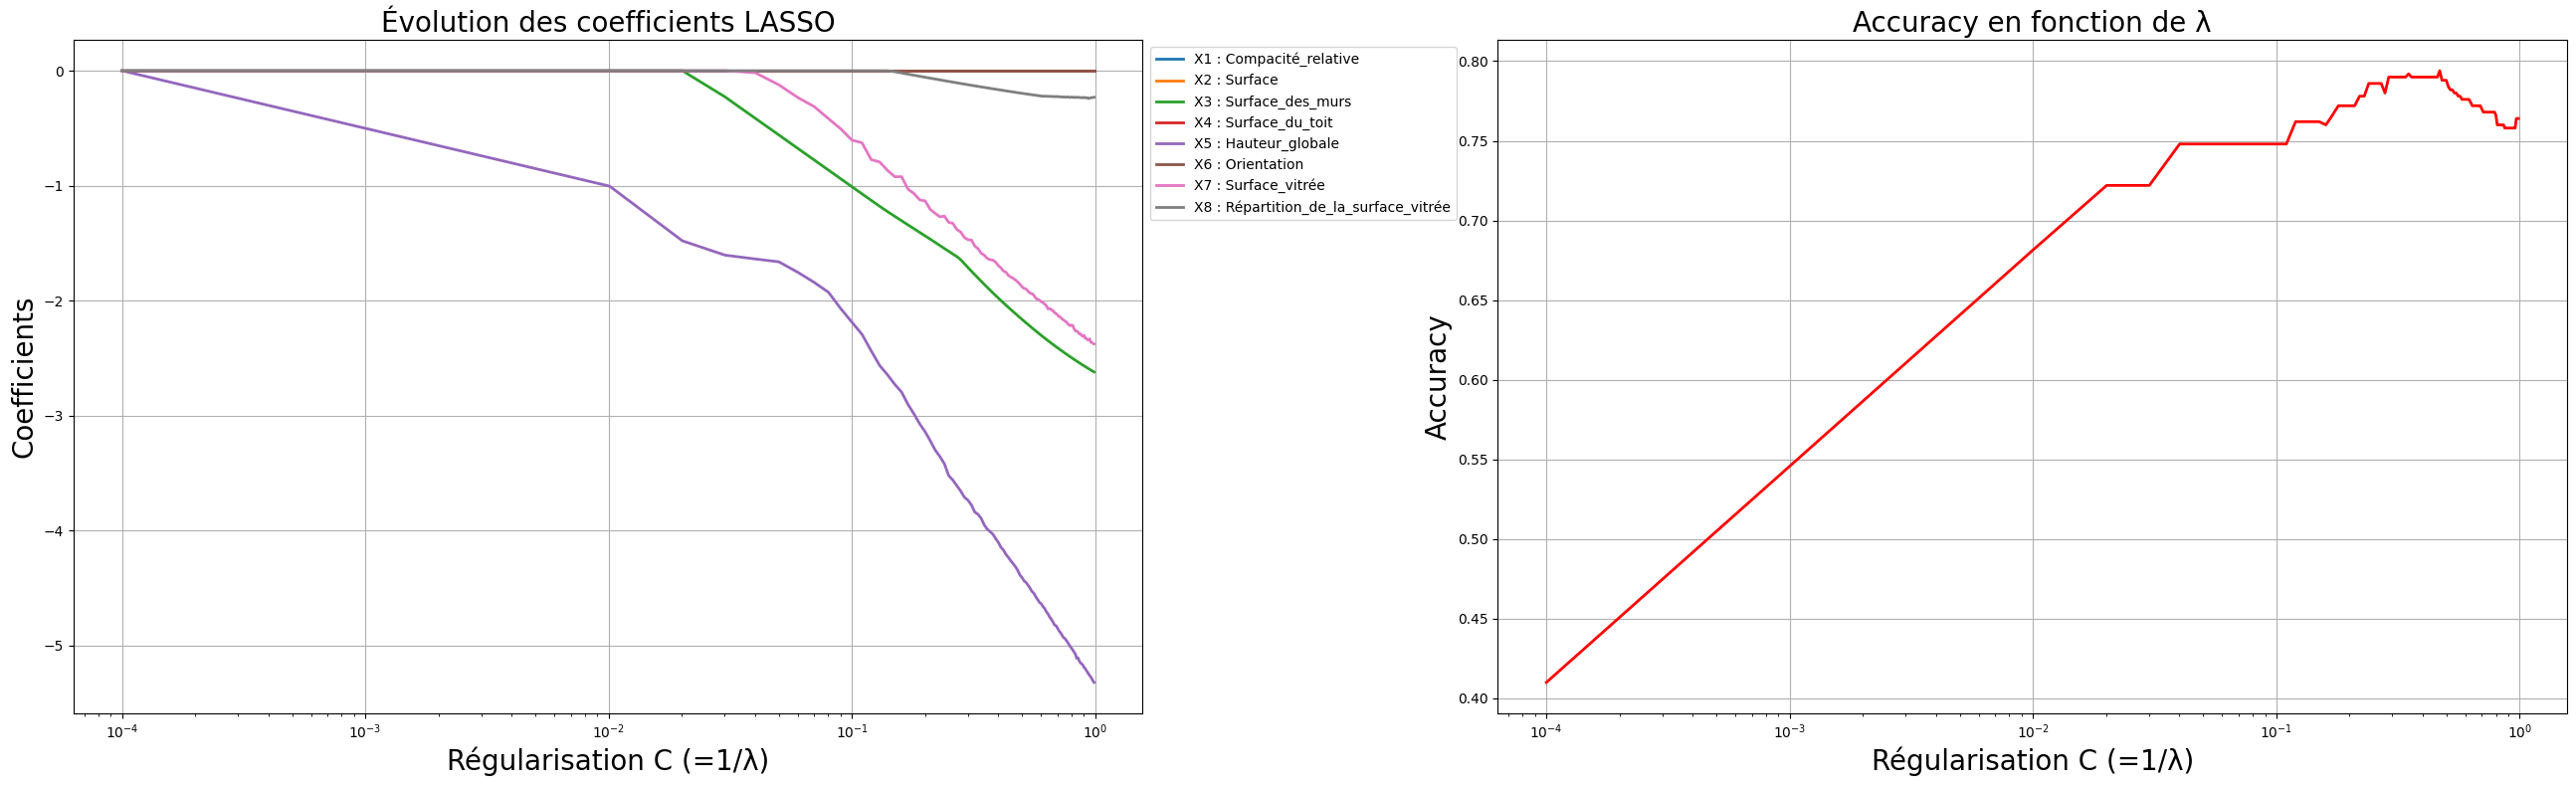

,X1 : Compacité_relative,X2 : Surface,X3 : Surface_des_murs,X4 : Surface_du_toit,X5 : Hauteur_globale,X6 : Orientation,X7 : Surface_vitrée,X8 : Répartition_de_la_surface_vitrée,lambda
0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0001
1,0.0,0.0,0.000000,0.0,-1.004129,0.0,0.000000,0.0,0.0101
2,0.0,0.0,0.000000,0.0,-1.479225,0.0,0.000000,0.0,0.0201
3,0.0,0.0,-0.227523,0.0,-1.603992,0.0,0.000000,0.0,0.0301
4,0.0,0.0,-0.414086,0.0,-1.637370,0.0,-0.017749,0.0,0.0401


In [ ]:
# @title Regression logistique lasso

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Convertir les noms des classes en entiers
class_mapping = {'Class 1': 1, 'Class 2': 2, 'Class 3': 3, 'Class 4': 4}
YTrain_numeric = np.array([class_mapping[c] for c in YTrain])
YTest_numeric = np.array([class_mapping[c] for c in YTest])

# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(XTrain)
X_test_scaled = scaler.transform(XTest)

labels = Xdata.columns.values
d = X_train_scaled.shape[1]
nTrain_lasso = X_train_scaled.shape[0]
nTest_lasso = X_test_scaled.shape[0]

step = 0.01
stock_lambda = np.arange(0.0001, 1, step)
nb_lambda = len(stock_lambda)

stock_beta = np.zeros((nb_lambda, d))
stock_acc_train = np.zeros(nb_lambda)

l = 0
for c in stock_lambda:

    LR = LogisticRegression(penalty='l1', solver='saga', C=c, max_iter=10000)
    LR.fit(X_train_scaled, YTrain_numeric)

    y_pred = LR.predict(X_train_scaled)
    acc = np.mean(y_pred == YTrain_numeric)

    stock_acc_train[l] = acc
    stock_beta[l] = LR.coef_[0]
    l += 1

fig = plt.figure(figsize=(26,8))

#Graphique de l'évolution des coefficients LASSO
ax1 = fig.add_subplot(1,2,1)
for j in range(d):
    ax1.plot(stock_lambda, stock_beta[:,j], lw=2, label=labels[j])
ax1.set_xscale("log")
ax1.set_xlabel("Régularisation C (=1/λ)", fontsize=20)
ax1.set_ylabel("Coefficients", fontsize=20)
ax1.set_title("Évolution des coefficients LASSO", fontsize=20)
ax1.grid()
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

# Grapique de l'accuracy
ax2 = fig.add_subplot(1,2,2)
ax2.plot(stock_lambda, stock_acc_train, lw=2, color='red')
ax2.set_xscale("log")
ax2.set_xlabel("Régularisation C (=1/λ)", fontsize=20)
ax2.set_ylabel("Accuracy", fontsize=20)
ax2.set_title("Accuracy en fonction de λ", fontsize=20)
ax2.grid()

plt.tight_layout()
plt.show()

# Sauvegarde
fig.savefig("LASSO_energy.pdf")
fig.savefig("LASSO_energy.png")

df_coef = pd.DataFrame(stock_beta, columns=labels)
df_coef["lambda"] = stock_lambda
df_coef.to_csv("coef_LASSO_energy.csv", index=False)
df_coef.head()

**Résultats de la régression LASSO**

Les résultats de la régression LASSO permettent d’identifier les variables les plus importantes pour la classification des bâtiments selon leur niveau de charge de chauffage.

Lors de l’exploration des valeurs du paramètre de régularisation λ, on observe qu’à partir de λ = 0.0101, seules trois variables explicatives restent non nulles, ce qui signifie qu’elles suffisent à elles seules pour obtenir une forte accuracy :

- X5 : Hauteur globale → coefficient ≈ –1.00
- X3 : Surface des murs → coefficient ≈ –0.23
- X7 : Surface vitrée → coefficient ≈ –0.02

**Variables retenues et interprétation**

- Hauteur globale (X5) : coefficient fortement négatif

    - Il s’agit de la variable la plus influente.
Un coefficient négatif indique que plus le bâtiment est haut, plus la charge de chauffage tend à être faible. Ce résultat est cohérent physiquement : les bâtiments plus hauts ont en général une forme plus compacte, ce qui réduit les déperditions thermiques.

- Surface des murs (X3) : coefficient négatif

    - Cette variable apparaît ensuite dans le modèle : une plus grande surface de murs est associée à une charge de chauffage plus faible. Ceci peut s’expliquer par une corrélation structurelle avec la hauteur globale (bâtiments verticalisés = murs plus hauts mais moins de surface de toiture, donc moins de pertes).

- Surface vitrée (X7) : coefficient très faible

    - Cette variable a un poids faible mais non nul, c'est-à-dire qu'elle joue un rôle mineur, mais contribue légèrement à réduire la charge de chauffage. Cela peut refléter un effet d’apport solaire (gains gratuits) dans certaines configurations, mais l’effet reste marginal dans cette base de données.

Les autres variables du dataset (compacité, surface totale, toiture, orientation…) sont entièrement éliminées par le LASSO car elles n’apportent aucune amélioration significative aux performances du modèle.


Ainsi, le modèle LASSO montre qu’il n’est pas nécessaire d’intégrer l’ensemble des variables architecturales : seules trois d’entre elles suffisent à prédire de manière fiable la classe de charge de chauffage, avec une bonne accuracy. Cette sélection automatique confirme que l’architecture verticale du bâtiment (hauteur + surface des murs) joue un rôle central dans ses besoins thermiques, tandis que les autres caractéristiques ont un impact négligeable dans le cadre de notre projet.

**Arbre de décision**

Un arbre de décision a été calibré puis élagué pour atteindre le meilleur compromis entre complexité et précision. L’arbre élagué met en évidence les variables les plus utilisées pour classer les bâtiments, en se concentrant sur un nombre limité de variables pour maximiser la simplicité et la performance du modèle.

L’importance relative de chaque variable est ainsi déterminée, ce qui permet d’identifier celles qui sont réellement pertinentes pour prédire la charge de chauffage.



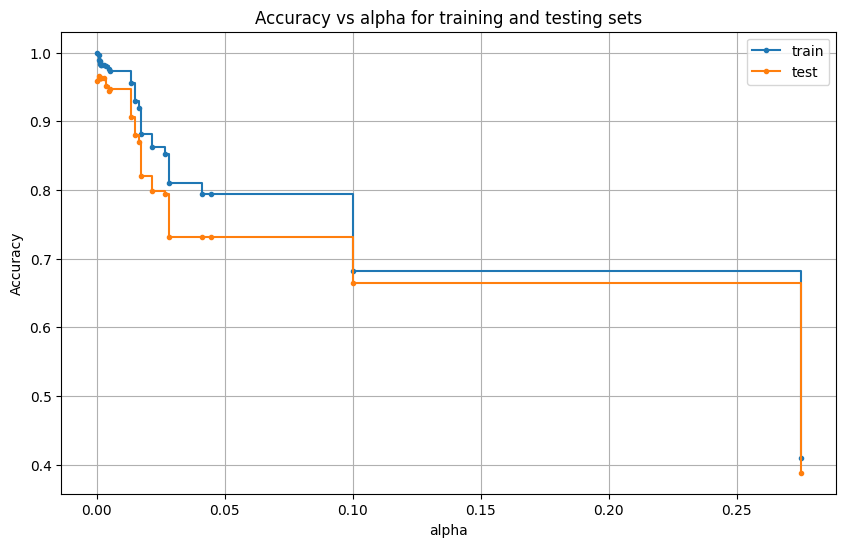

Nb feuilles DT_elague = 36
Risk Train DT_elague = 0.0040000000000000036
Risk Test DT_elague = 0.03358208955223885


In [ ]:
# @title Importation des modules nécessaires
from sklearn.tree import DecisionTreeClassifier
import graphviz
from sklearn import tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np

# @title Création et calibration de l'arbre de décision
# Fit du Decision Tree :
DT = DecisionTreeClassifier(random_state=0)
path = DT.cost_complexity_pruning_path(XTrain, YTrain)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

stocks_DT = []
stock_accuracy_train = []
stock_accuracy_test = []

for ccp_alpha in ccp_alphas:
    DT_aplpha = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    DT_aplpha.fit(XTrain, YTrain)
    stocks_DT.append(DT_aplpha)
    # Accuracy Train DT :
    YhatTrain = DT_aplpha.predict(XTrain)
    stock_accuracy_train.append(np.sum(YTrain==YhatTrain)/nTrain)
    # Accuracy Test DT :
    YhatTest = DT_aplpha.predict(XTest)
    stock_accuracy_test.append(np.sum(YTest==YhatTest)/nTest)


fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel("alpha")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, stock_accuracy_train, marker=".", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, stock_accuracy_test, marker=".", label="test", drawstyle="steps-post")
ax.legend()
plt.grid(True)
plt.show()

# @title Elaguage de l'arbre
# Fit Decision Tree avec élaguage :
# Selection du ccp_alpha qui maximise l'accuracy test
optimal_ccp_alpha = ccp_alphas[np.argmax(stock_accuracy_test)]

DT_elague = DecisionTreeClassifier(random_state=0, ccp_alpha=optimal_ccp_alpha)
DT_elague.fit(XTrain, YTrain)

# Vérification nombre feuilles terminales :
nb_leaves = DT_elague.get_n_leaves()
print('Nb feuilles DT_elague =', nb_leaves)
# Risk Train DT :
YhatTrain = DT_elague.predict(XTrain)
Risk_DT_TRain = 1-np.sum(YTrain==YhatTrain)/nTrain
print('Risk Train DT_elague =', Risk_DT_TRain)
# Risk Test DT :
YhatTest = DT_elague.predict(XTest)
Risk_DT_Test = 1-np.sum(YTest==YhatTest)/nTest
print('Risk Test DT_elague =', Risk_DT_Test)

In [ ]:
# @title Essais arbre de décisions

from sklearn.tree import DecisionTreeClassifier

#Lancer l'arbre de décisions
DT_data = DecisionTreeClassifier(random_state = 0)
DT_data.fit(XTrain, YTrain)

#nombre de feuilles

nb_leaves = DT_data.get_n_leaves()
print('Nb feuilles DT =', nb_leaves)

#Risque sur la base d'apprentissage

YhatTrain = DT_data.predict(XTrain)
Risk_DT_TRain = 1-np.sum(YTrain==YhatTrain)/nTrain
print('Risque sur apprentissage DT =', Risk_DT_TRain)

#Risque sur la base de Test

YhatTest = DT_data.predict(XTest)
Risk_DT_Test = 1-np.sum(YTest==YhatTest)/nTest
print('Risque sur test DT =', Risk_DT_Test)

Nb feuilles DT = 43
Risque sur apprentissage DT = 0.0
Risque sur test DT = 0.04104477611940294


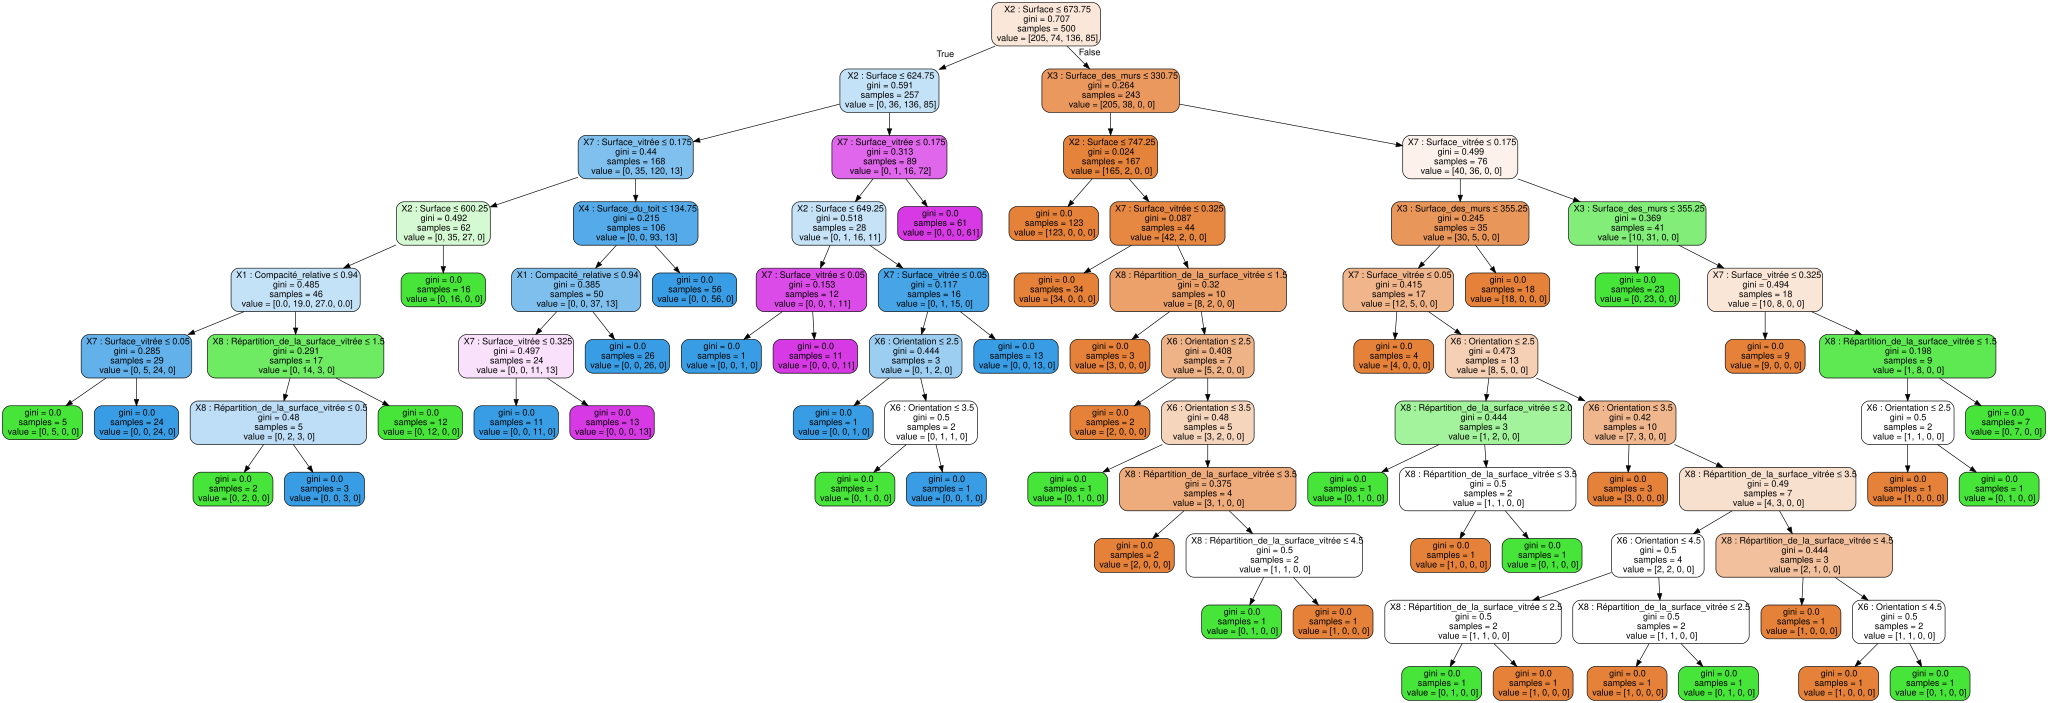

In [ ]:
# @title Représentation graphique

import graphviz
from sklearn import tree

d = XTrain.shape[1]

dot_data = tree.export_graphviz(DT_data, out_file=None)
graph = graphviz.Source(dot_data)

dot_data = tree.export_graphviz(DT_data, out_file=None, feature_names=data.columns.values[0:d],  filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph

In [ ]:
#On essaie avec au moins 10 données par feuilles

start_tracker = tracker_DT.start()

#Lancer l'arbre de décisions
DT_data = DecisionTreeClassifier(random_state = 0, min_samples_leaf = 5)
DT_data.fit(XTrain, YTrain)

#nombre de feuilles

nb_leaves = DT_data.get_n_leaves()
print('Nb feuilles DT =', nb_leaves)

#Risque sur la base d'apprentissage

YhatTrain = DT_data.predict(XTrain)
Risk_DT_TRain = 1-np.sum(YTrain==YhatTrain)/nTrain
print('Risque sur apprentissage DT =', Risk_DT_TRain)

#Risque sur la base de Test

YhatTest = DT_data.predict(XTest)
Risk_DT_Test = 1-np.sum(YTest==YhatTest)/nTest
print('Risque sur test DT =', Risk_DT_Test)

emission_DT = tracker_DT.stop()
print(f"Estimated carbon emissions from Decision Tree: {tracker_DT.final_emissions * 1000:.6f} g CO2eq")


[codecarbon INFO @ 13:31:30] Energy consumed for RAM : 0.000000 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 13:31:30] Delta energy consumed for CPU with constant : 0.000000 kWh, power : 42.5 W
[codecarbon INFO @ 13:31:30] Energy consumed for All CPU : 0.000000 kWh
[codecarbon INFO @ 13:31:30] 0.000000 kWh of electricity and 0.000000 L of water were used since the beginning.


Nb feuilles DT = 25
Risque sur apprentissage DT = 0.02400000000000002
Risque sur test DT = 0.05597014925373134
Estimated carbon emissions from Decision Tree: 0.000116 g CO2eq


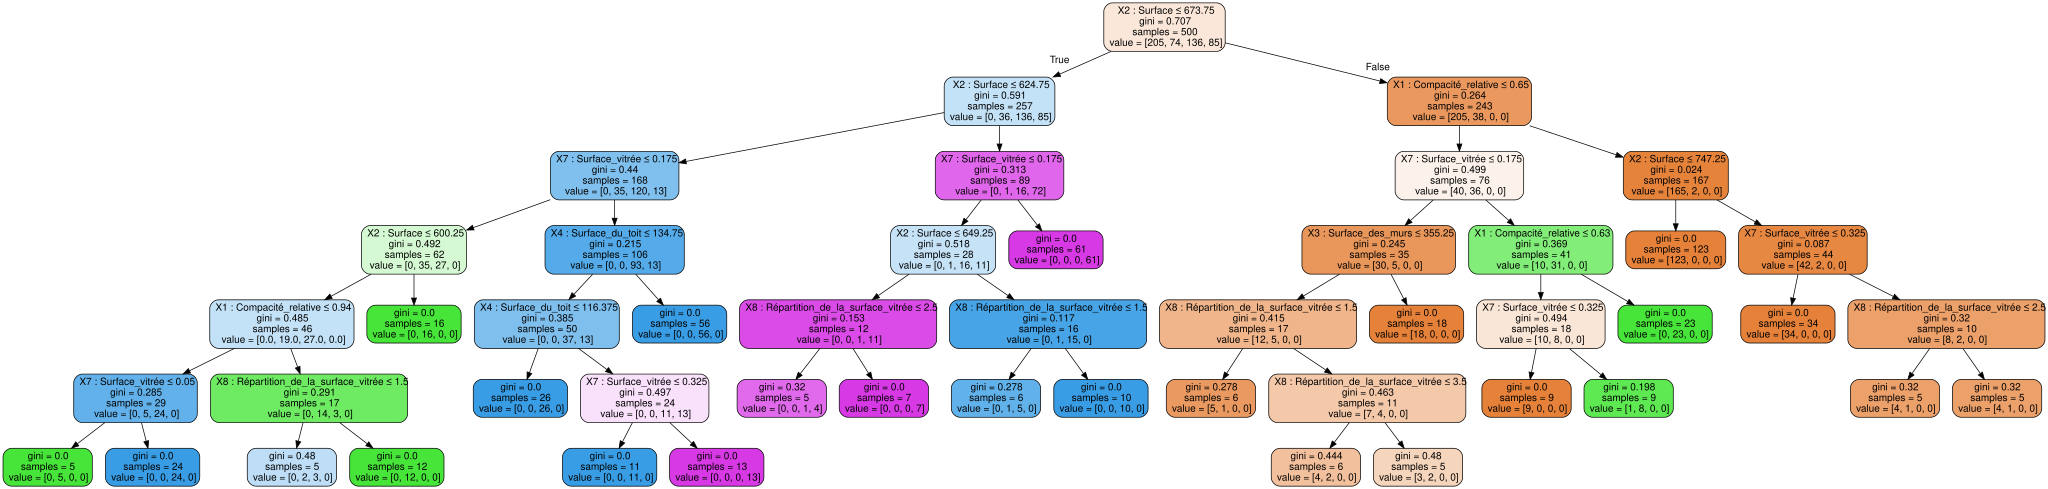

In [ ]:
# Représentation graphique

import graphviz
from sklearn import tree

d = XTrain.shape[1]

dot_data = tree.export_graphviz(DT_data, out_file=None)
graph = graphviz.Source(dot_data)

dot_data = tree.export_graphviz(DT_data, out_file=None, feature_names=data.columns.values[0:d],  filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph

# Analyse des arbres générés

- On observe que , bien que performant lorsqu'aucun minimum d'observations par feuille est rentré, on observe bon nombre de feuille à valeur unique dans l'abre dans ce cas. La performance alors réalisée avec un base de test différente peut alors être différente.

- Lorsque le nombre minimal d'observations par feuille est de 10 on perd pourtant en performance bien que le nombre totale de feuille est presque réduit au tier. C'est alors en fixant le nombre d'observations minimal par feuille qu'on obtient un risque faible et un nombre de feuille réduit (presque moitié moins que dans le premier cas).

- On observe également dans les quelques feuilles mixes que les différentes observations sont au pires répartie dans 2 classes différentes adjacentes. Nous avons dû prédéfinir ces classes en traçant des frontières subjectives, ainsi il ne semble pas dramatique, et plutôt logique d'avoir quelques dépassement lorsque nous ne surdécoupons pas.

- Enfin dans l'objectif IS, il sera pertinent de comparer pour les différents tests le rapport entre l'accuracy et la consommation du code, nous pouvons déjà faire l'hypothèse qu'un moindre nombre de feuille entraine une moindre consommation d'énergie, maintenant il faudra en évaluer l'ordre de grandeur.

**Résultats de l'arbre de décision**

L'arbre de décision élagué, sélectionné pour son risque le plus bas (ou l'accuracy la plus haute) sur la base de test, a atteint une précision de 96.64% (avec un risque de 3.36%). Ce modèle met en évidence plusieurs facteurs déterminants, dont l'influence est classée comme suit :

- X2 : Surface (La plus influente, avec une contribution majeure à la séparation des classes)
- X7 : Surface vitrée (Deuxième facteur le plus influent, contribuant de manière significative à la prédiction)
- X3 : Surface des murs (Un facteur notable dans le processus de décision)
- X1 : Compacité relative (Contribue à la classification, mais à un degré moindre que les précédentes)
- X8 : Répartition de la surface vitrée (Une influence plus modeste sur la prédiction)
- X6 : Orientation (Son impact sur la décision est faible)
- X4 : Surface du toit (Son impact sur la décision est faible)

Il est intéressant de noter que la Hauteur globale (X5) n'a aucune influence détectable dans cet arbre de décision (sa contribution à la réduction de l'impureté est nulle), ce qui contraste avec son rôle significatif observé dans la régression LASSO. Cette différence illustre que chaque modèle identifie et utilise les caractéristiques de manière distincte pour effectuer ses prédictions. L'arbre de décision, dans ce cas, se base principalement sur la surface, la surface vitrée et la surface des murs comme principaux critères de classification.

**Résultats et sélection finale des variables**

En combinant les résultats de la régression LASSO et de l’arbre de décision, les variables les plus influentes sur la prédiction de la charge de chauffage ont été identifiées. Certaines variables peuvent être mises de côté si elles apportent peu d’information ou si leur collecte est difficile/complexe.

Pour notre projet, les variables sélectionnées sont donc :

- X1 : Compacité relative : Cette variable a été mise en évidence par l'arbre de décision. Elle est importante car un bâtiment plus compact a généralement une surface de déperdition thermique plus faible par rapport à son volume, ce qui réduit les besoins en chauffage.

- X2 : Surface : Il s'agit de la variable la plus influente dans l'arbre de décision. La surface totale du bâtiment est un facteur direct qui impacte la quantité d'énergie nécessaire pour le chauffer, car plus la surface est grande, plus le volume à chauffer est important et les pertes thermiques potentielles sont élevées.

- X3 : Surface des murs : Cette variable est significative dans les deux modèles (régression LASSO et arbre de décision). La surface des murs est une composante majeure de l'enveloppe du bâtiment et joue un rôle crucial dans les transferts thermiques avec l'extérieur. Une plus grande surface de murs peut augmenter les déperditions si l'isolation n'est pas adéquate.

- X5 : Hauteur globale : Bien que son influence dans l'arbre de décision soit moindre, la régression LASSO la considère comme très influente. La hauteur globale est liée à la forme du bâtiment et à sa compacité verticale, qui peut affecter la distribution de la chaleur et les pertes énergétiques. Les bâtiments plus hauts peuvent être plus compacts et donc plus efficaces énergétiquement si leur conception est optimisée.

- X7 : Surface vitrée : Cette variable est présente dans les deux modèles. Bien que son impact puisse être modéré comparé à d'autres facteurs, la surface vitrée est pertinente car les fenêtres sont des points faibles en termes d'isolation mais peuvent aussi apporter des gains solaires passifs, réduisant ainsi la charge de chauffage selon l'orientation et le type de vitrage.

Ces variables permettent de prédire efficacement le niveau de charge de chauffage à partir des plans ou caractéristiques du bâtiment.

Nous allons ainsi choisir de ne conserver que ces variables d'intérêts. Nous ne possèdons plus aucune variable catégorielle.

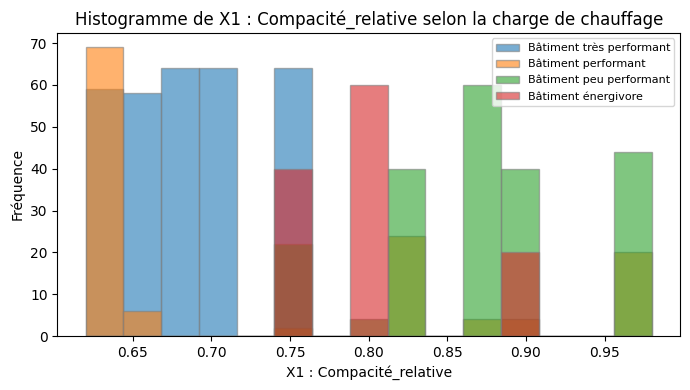

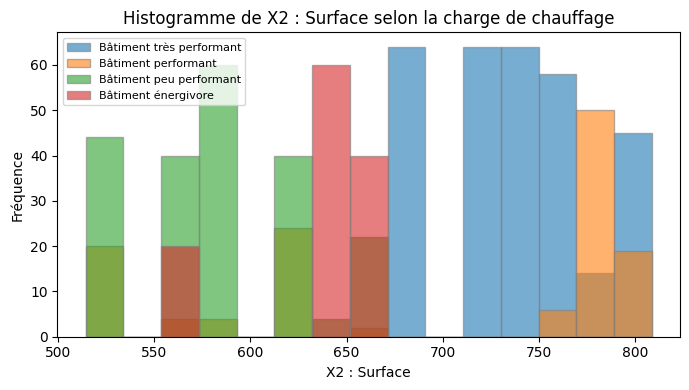

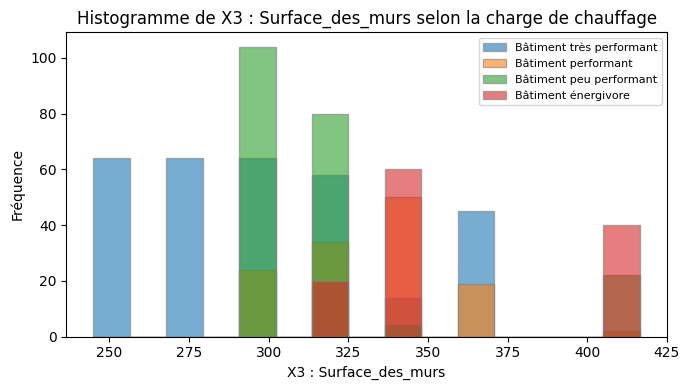

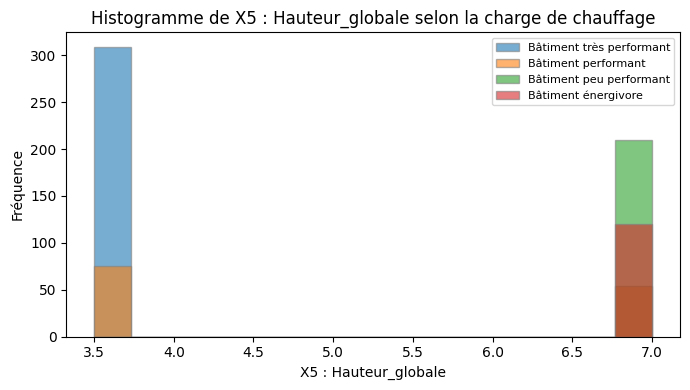

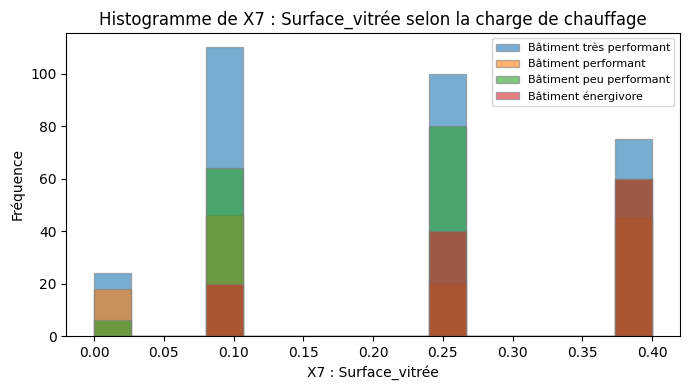

In [ ]:
#@title Histogrammes des variables d'intérêts en fonction des classes
selected_features = [
    'X1 : Compacité_relative',
    'X2 : Surface',
    'X3 : Surface_des_murs',
    'X5 : Hauteur_globale',
    'X7 : Surface_vitrée'
]
class_column = 'Classe_Y1'

class_name_mapping = {
    'Class 1': 'Bâtiment très performant',
    'Class 2': 'Bâtiment performant',
    'Class 3': 'Bâtiment peu performant',
    'Class 4': 'Bâtiment énergivore'
}

class_order = list(class_name_mapping.values())

data['Classe'] = data[class_column].map(class_name_mapping)
import numpy as np
import matplotlib.pyplot as plt

def plot_histograms_multiclass(data, features, class_col, class_order, bins=15):
    for feature in features:
        plt.figure(figsize=(7, 4))

        # calcul des bins globaux pour une comparaison équitable
        values = data[feature].dropna()
        bins_hist = np.histogram_bin_edges(values, bins=bins)

        for classe in class_order:
            subset = data[data[class_col] == classe][feature]
            plt.hist(
                subset,
                bins=bins_hist,
                alpha=0.6,
                edgecolor='gray',
                label=classe
            )

        plt.title(f"Histogramme de {feature} selon la charge de chauffage")
        plt.xlabel(feature)
        plt.ylabel("Fréquence")
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
plot_histograms_multiclass(
    data=data,
    features=selected_features,
    class_col='Classe',
    class_order=class_order
)
data.drop(columns=['Classe'], inplace=True)

Les histogrammes des variables retenues montrent une différenciation progressive des classes de charge de chauffage, traduisant leur pouvoir discriminant. Globalement, les bâtiments très performants se caractérisent par des valeurs plus faibles des variables liées à la taille et à l’enveloppe du bâtiment, telles que la surface totale, la surface des murs et la surface vitrée, ce qui correspond à des déperditions thermiques limitées. À l’inverse, les bâtiments énergivores présentent majoritairement des valeurs plus élevées pour ces variables, indiquant des besoins en chauffage plus importants.

La compacité relative et la hauteur globale contribuent également à la séparation des classes, soulignant l’influence de la forme du bâtiment sur son efficacité énergétique. Bien que certaines zones de recouvrement existent entre les classes, les distributions montrent des tendances distinctes, confirmant la pertinence des variables sélectionnées par la régression LASSO et l’arbre de décision pour la prédiction de la charge de chauffage.

#Mise en place et comparaison des classifieurs

Dans cette partie, nous implémentons et comparons plusieurs modèles de classification : la régression logistique, LDA, QDA, le classifieur euclidien, le Bayes naïf, le Perceptron, le KNN, l’arbre de décision et le Random Forest.
Ces modèles ont été choisis car ils couvrent des approches très différentes, allant de méthodes linéaires simples à des modèles plus complexes et non linéaires. L’objectif est de comparer leurs performances, leur stabilité entre les phases d’apprentissage et de test, ainsi que leur capacité à généraliser, afin de sélectionner le modèle le plus adapté à notre problème.

In [ ]:
# @title Classifieur Bayes Naïf
# implémentation du classifieur Bayes Naïf
import numpy as np
from scipy.stats import norm

start_tracker = tracker_BN.start()

class NaiveBayesClassifier:
    def __init__(self):
        self.priors = None
        self.numerical_params = {} # Stores (mu, sigma) for numerical features per class
        self.categorical_params = {} # Stores probabilities for categorical features per class
        self.K = None # Number of classes
        self.feature_types = {} # To store if a feature is 'numerical' or 'categorical'
        self.categorical_max_values = {} # Max value for categorical features to define T

    def _estimation_priors(self, Y):
        n = len(Y)
        for k in range(self.K):
            self.priors[k] = np.sum(Y == (k + 1)) / n

    def _estimation_vraisemblance_cat(self, Xj, Y, feature_idx):
        # Determine T (max category value + 1) for this specific feature
        max_val = int(Xj.max()) if Xj.size > 0 else 0
        T = max_val + 1
        self.categorical_max_values[feature_idx] = T # Store T for this feature

        pHatj = np.zeros((self.K, T))

        for k in range(self.K):
            nk = np.sum(Y == (k + 1))
            # Use Laplace smoothing: add 1 to count and T to denominator (number of possible categories)
            for t in range(T):
                count = np.sum(Xj[np.where(Y == (k + 1))] == t)
                pHatj[k, t] = (count + 1) / (nk + T) if (nk + T) > 0 else 1.0 / T # Avoid division by zero

        self.categorical_params[feature_idx] = pHatj

    def _estimation_vraisemblance_num(self, Xj, Y, feature_idx):
        mu_j = np.zeros(self.K)
        sigma_j = np.zeros(self.K)

        for k in range(self.K):
            Ik = np.where(Y == (k + 1))
            if len(Ik[0]) == 0: # If a class has no samples for this feature in training
                mu_j[k] = np.mean(Xj) # Use overall mean
                sigma_j[k] = np.std(Xj) # Use overall std
            else:
                mu_j[k] = np.mean(Xj[Ik[0]])
                sigma_j[k] = np.std(Xj[Ik[0]])

            if sigma_j[k] == 0: # Avoid zero std deviation for norm.pdf
                sigma_j[k] = 1e-6 # Small epsilon

        self.numerical_params[feature_idx] = (mu_j, sigma_j)

    def fit(self, XTrain, YTrain_numeric, feature_names):
        self.K = len(np.unique(YTrain_numeric))
        self.priors = np.zeros(self.K)
        self._estimation_priors(YTrain_numeric)

        for i, col_name in enumerate(feature_names):
            Xj = XTrain[:, i]
            # Identify categorical features based on column names
            if 'Orientation' in col_name or 'Répartition_de_la_surface_vitrée' in col_name:
                self.feature_types[i] = 'categorical'
                self._estimation_vraisemblance_cat(Xj, YTrain_numeric, i)
            else: # Assume all other features are numerical
                self.feature_types[i] = 'numerical'
                self._estimation_vraisemblance_num(Xj, YTrain_numeric, i)

    def predict(self, XTest):
        nTest = XTest.shape[0]
        YhatTest = np.zeros(nTest)

        for i in range(nTest): # For each test observation
            Posteriori_num = np.zeros(self.K)
            for k in range(self.K): # For each class
                likelihood_product = self.priors[k]

                for feature_idx in range(XTest.shape[1]):
                    feature_value = XTest[i, feature_idx]

                    if self.feature_types[feature_idx] == 'numerical':
                        mu, sigma = self.numerical_params[feature_idx]
                        pdf_val = norm.pdf(feature_value, loc=mu[k], scale=sigma[k])
                        likelihood_product *= pdf_val
                    else: # Categorical feature
                        pHatj = self.categorical_params[feature_idx]
                        max_val_for_feature = self.categorical_max_values[feature_idx]
                        # Ensure feature_value is within expected range for indexing
                        if feature_value >= 0 and feature_value < max_val_for_feature: # Check bounds for categorical index
                            pmf_val = pHatj[k, int(feature_value)]
                        else:
                            # If an unseen category in test, assign a small probability (consistent with Laplace smoothing)
                            pmf_val = 1.0 / max_val_for_feature # Default if category not handled
                        likelihood_product *= pmf_val

                Posteriori_num[k] = likelihood_product

            # Handle cases where all posterior_num are zero (e.g., due to extremely small likelihoods)
            if np.sum(Posteriori_num) == 0:
                YhatTest[i] = np.random.randint(1, self.K + 1) # Random guess if all likelihoods are zero
            else:
                YhatTest[i] = np.argmax(Posteriori_num) + 1 # Convert back to 1-indexed class label

        return YhatTest

# --- Adaptation to your project's data ---

# 1. Convert class labels from strings to numeric (1-indexed for the classifier)
class_mapping = {'Class 1': 1, 'Class 2': 2, 'Class 3': 3, 'Class 4': 4}
YTrain_numeric = np.array([class_mapping[c] for c in YTrain])
YTest_numeric = np.array([class_mapping[c] for c in YTest])

# 2. Get feature names from the original Xdata DataFrame
# X is a numpy array, Xdata is the DataFrame it was derived from.
# We need the column names of Xdata *before* Y columns were dropped.
# Assuming Xdata in the previous cell represents the features used for XTrain/XTest
feature_names = Xdata.columns.values # Get current column names of Xdata

# 3. Instantiate, train, and predict using the NaiveBayesClassifier
nb_classifier = NaiveBayesClassifier()
nb_classifier.fit(XTrain, YTrain_numeric, feature_names)

YhatTest_numeric = nb_classifier.predict(XTest)

# 4. Calculate and print the global error rate
errGlobalTest = np.sum(YhatTest_numeric != YTest_numeric) / nTest
print('Taux erreur global du classifieur de Bayes Naif sur la base de test =', errGlobalTest)

emission_bn = tracker_BN.stop()
print(f"Estimated carbon emissions from BN: {tracker_BN.final_emissions * 1000:.6f} g CO2eq")


[codecarbon WARNING @ 13:32:41] Already started tracking
[codecarbon WARNING @ 13:32:42] Tracker already stopped !
[codecarbon INFO @ 13:32:42] Energy consumed for RAM : 0.000173 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 13:32:42] Delta energy consumed for CPU with constant : 0.000725 kWh, power : 42.5 W
[codecarbon INFO @ 13:32:42] Energy consumed for All CPU : 0.000734 kWh
[codecarbon INFO @ 13:32:42] 0.000907 kWh of electricity and 0.000000 L of water were used since the beginning.


Taux erreur global du classifieur de Bayes Naif sur la base de test = 0.26865671641791045
Estimated carbon emissions from BN: 0.669251 g CO2eq


In [ ]:
# @title Classifieur QDA

start_tracker = tracker_QDA.start()

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

print("==== CLASSIFIEUR : QDA ====")

# Apprentissage du modèle
QDA_model = QuadraticDiscriminantAnalysis(reg_param=0.01)
QDA_model.fit(XTrain, YTrain)

# Prédictions sur train et test
YhatTrain_QDA = QDA_model.predict(XTrain)
YhatTest_QDA = QDA_model.predict(XTest)

# Taux d'erreur global (risque empirique)
risk_train_QDA = np.mean(YhatTrain_QDA != YTrain)
risk_test_QDA  = np.mean(YhatTest_QDA  != YTest)

print(f"Taux d'erreur global (train) = {risk_train_QDA:.3f}")
print(f"Taux d'erreur global (test)  = {risk_test_QDA:.3f}")
print(f"Taux de bonne classification (train) = {1 - risk_train_QDA:.3f}")
print(f"Taux de bonne classification (test)  = {1 - risk_test_QDA:.3f}")

emission_qda = tracker_QDA.stop()
print(f"Estimation du carbone émis par la QDA: {tracker_QDA.final_emissions * 1000:.6f} g CO2eq")


[codecarbon INFO @ 13:32:46] Energy consumed for RAM : 0.000000 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 13:32:46] Delta energy consumed for CPU with constant : 0.000000 kWh, power : 42.5 W
[codecarbon INFO @ 13:32:46] Energy consumed for All CPU : 0.000000 kWh
[codecarbon INFO @ 13:32:46] 0.000000 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 13:32:46] The CSV format has changed, backing up old emission file.


==== CLASSIFIEUR : QDA ====
Taux d'erreur global (train) = 0.224
Taux d'erreur global (test)  = 0.295
Taux de bonne classification (train) = 0.776
Taux de bonne classification (test)  = 0.705
Estimation du carbone émis par la QDA: 0.000222 g CO2eq


In [ ]:
#@title Classifieur LDA

start_tracker = tracker_LDA.start()

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

print("==== CLASSIFIEUR : LDA ====")

# Apprentissage
LDA_model = LinearDiscriminantAnalysis()
LDA_model.fit(XTrain, YTrain)

# Prédictions
YhatTrain_LDA = LDA_model.predict(XTrain)
YhatTest_LDA  = LDA_model.predict(XTest)

# Taux d'erreur global (risque empirique)
risk_train_LDA = np.mean(YhatTrain_LDA != YTrain)
risk_test_LDA  = np.mean(YhatTest_LDA  != YTest)

print(f"Taux d'erreur global (train) = {risk_train_LDA:.3f}")
print(f"Taux d'erreur global (test)  = {risk_test_LDA:.3f}")
print(f"Taux de bonne classification (train) = {1 - risk_train_LDA:.3f}")
print(f"Taux de bonne classification (test)  = {1 - risk_test_LDA:.3f}")

emission_lda = tracker_LDA.stop()
print(f"Estimation de l'émission carbone par la LDA: {tracker_LDA.final_emissions * 1000:.6f} g CO2eq")


[codecarbon INFO @ 13:32:48] Energy consumed for RAM : 0.000000 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 13:32:48] Delta energy consumed for CPU with constant : 0.000000 kWh, power : 42.5 W
[codecarbon INFO @ 13:32:48] Energy consumed for All CPU : 0.000000 kWh
[codecarbon INFO @ 13:32:48] 0.000000 kWh of electricity and 0.000000 L of water were used since the beginning.


==== CLASSIFIEUR : LDA ====
Taux d'erreur global (train) = 0.244
Taux d'erreur global (test)  = 0.302
Taux de bonne classification (train) = 0.756
Taux de bonne classification (test)  = 0.698
Estimation de l'émission carbone par la LDA: 0.000107 g CO2eq


In [ ]:
#@title CLassifieur Perceptron

start_tracker = tracker_Perc.start()

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

print("==== CLASSIFIEUR : PERCEPTRON ====")


# Standardisation

scaler_perc = StandardScaler()
XTrain_perc = scaler_perc.fit_transform(XTrain)
XTest_perc  = scaler_perc.transform(XTest)


# Perceptron binaire = algorithme du cours (Y in {-1, +1})

def perceptron_binaire_cours(X, y, max_epochs=1000):
    n, d = X.shape
    beta = np.zeros(d + 1)  # inclut beta0

    for epoch in range(max_epochs):
        errors = 0
        for i in range(n):
            x_i = np.concatenate(([1.0], X[i]))  # [1, X1,...,Xd]
            y_hat = np.sign(beta @ x_i)
            if y_hat == 0:
                y_hat = 1  # convention

            # condition d'erreur : Y_hat(i) * Y(i) < 0 (ou <= 0)
            if y_hat * y[i] <= 0:
                beta += y[i] * x_i
                errors += 1

        # si plus d'erreurs sur un passage complet -> on arrête
        if errors == 0:
            break

    return beta


# Extension multi-classes

classes = np.unique(YTrain)
betas = {}  # un vecteur beta par classe

for c in classes:
    y_bin = np.where(YTrain == c, 1, -1)  # c -> +1, autres -> -1
    beta_c = perceptron_binaire_cours(XTrain_perc, y_bin, max_epochs=1000)
    betas[c] = beta_c

# Fonction de décision : on choisit la classe avec le score le plus grand

def decision_perceptron_ovr(X, betas, classes):
    n = X.shape[0]
    scores = np.zeros((n, len(classes)))
    for j, c in enumerate(classes):
        beta_c = betas[c]
        beta0 = beta_c[0]
        w = beta_c[1:]
        scores[:, j] = beta0 + X @ w
    idx_max = np.argmax(scores, axis=1)
    return classes[idx_max]

# Prédictions

YhatTrain_perc = decision_perceptron_ovr(XTrain_perc, betas, classes)
YhatTest_perc  = decision_perceptron_ovr(XTest_perc,  betas, classes)

risk_train_perc = np.mean(YhatTrain_perc != YTrain)
risk_test_perc  = np.mean(YhatTest_perc  != YTest)

print(f"Taux d'erreur global (train) = {risk_train_perc:.3f}")
print(f"Taux d'erreur global (test)  = {risk_test_perc:.3f}")
print(f"Taux de bonne classification (train) = {1 - risk_train_perc:.3f}")
print(f"Taux de bonne classification (test)  = {1 - risk_test_perc:.3f}")

emission_perc = tracker_Perc.stop()
print(f"Estimation de l'émission carbone par Perceptron: {tracker_Perc.final_emissions * 1000:.6f} g CO2eq")


==== CLASSIFIEUR : PERCEPTRON ====


[codecarbon INFO @ 13:33:06] Energy consumed for RAM : 0.000041 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 13:33:06] Delta energy consumed for CPU with constant : 0.000175 kWh, power : 42.5 W
[codecarbon INFO @ 13:33:06] Energy consumed for All CPU : 0.000175 kWh
[codecarbon INFO @ 13:33:06] 0.000216 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 13:33:06] The CSV format has changed, backing up old emission file.


Taux d'erreur global (train) = 0.200
Taux d'erreur global (test)  = 0.239
Taux de bonne classification (train) = 0.800
Taux de bonne classification (test)  = 0.761
Estimation de l'émission carbone par Perceptron: 0.159405 g CO2eq


In [ ]:
#@title Classifieur Régression Logistique

start_tracker = tracker_LR.start()

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

print("==== CLASSIFIEUR : RÉGRESSION LOGISTIQUE ====")

# Standardisation (comme on le fait dans les TD pour les modèles linéaires)
scaler_rl = StandardScaler()
XTrain_rl = scaler_rl.fit_transform(XTrain)
XTest_rl  = scaler_rl.transform(XTest)

# Modèle de régression logistique multi-classes
RL_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=10000,
    random_state=0
)

# Apprentissage
RL_model.fit(XTrain_rl, YTrain)

# Prédictions
YhatTrain_RL = RL_model.predict(XTrain_rl)
YhatTest_RL  = RL_model.predict(XTest_rl)

# Taux d'erreur global
risk_train_RL = np.mean(YhatTrain_RL != YTrain)
risk_test_RL  = np.mean(YhatTest_RL  != YTest)

print(f"Taux d'erreur global (train) = {risk_train_RL:.3f}")
print(f"Taux d'erreur global (test)  = {risk_test_RL:.3f}")
print(f"Taux de bonne classification (train) = {1 - risk_train_RL:.3f}")
print(f"Taux de bonne classification (test)  = {1 - risk_test_RL:.3f}")
print("")

emissions_lr = tracker_LR.stop()
print(f"Estimation de l'émisson carbone par la régression logistique : {tracker_LR.final_emissions * 1000:.6f} g CO2eq")



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[codecarbon INFO @ 13:33:10] Energy consumed for RAM : 0.000000 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 13:33:10] Delta energy consumed for CPU with constant : 0.000000 kWh, power : 42.5 W
[codecarbon INFO @ 13:33:10] Energy consumed for All CPU : 0.000000 kWh
[codecarbon INFO @ 13:33:10] 0.000000 kWh of electricity and 0.000000 L of water were used since the beginning.


==== CLASSIFIEUR : RÉGRESSION LOGISTIQUE ====
Taux d'erreur global (train) = 0.224
Taux d'erreur global (test)  = 0.280
Taux de bonne classification (train) = 0.776
Taux de bonne classification (test)  = 0.720

Estimation de l'émisson carbone par la régression logistique : 0.000276 g CO2eq


In [ ]:
#@title Classifieur Euclidien
start_tracker = tracker_NC.start()

from sklearn.neighbors import NearestCentroid
from sklearn.preprocessing import StandardScaler
import numpy as np

print("==== CLASSIFIEUR : EUCLIDIEN ====")

# 1) Standardisation
scaler_eucl = StandardScaler()
XTrain_eucl = scaler_eucl.fit_transform(XTrain)
XTest_eucl  = scaler_eucl.transform(XTest)

# 2) Classifieur euclidien = un barycentre par classe + distance euclidienne
eucl_model = NearestCentroid()

# Apprentissage
eucl_model.fit(XTrain_eucl, YTrain)

# Prédictions
YhatTrain_eucl = eucl_model.predict(XTrain_eucl)
YhatTest_eucl  = eucl_model.predict(XTest_eucl)

# 3) Taux d'erreur global (risque empirique)
risk_train_eucl = np.mean(YhatTrain_eucl != YTrain)
risk_test_eucl  = np.mean(YhatTest_eucl  != YTest)

print(f"Taux d'erreur global (train) = {risk_train_eucl:.3f}")
print(f"Taux d'erreur global (test)  = {risk_test_eucl:.3f}")
print(f"Taux de bonne classification (train) = {1 - risk_train_eucl:.3f}")
print(f"Taux de bonne classification (test)  = {1 - risk_test_eucl:.3f}")
print("")

emission_Eucl = tracker_NC.stop()
print(f"Estimation de l'émission carbone par le classifieur euclidien : {tracker_NC.final_emissions * 1000:.6f} g CO2eq")



[codecarbon INFO @ 13:33:29] Energy consumed for RAM : 0.000000 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 13:33:29] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 13:33:29] Energy consumed for All CPU : 0.000001 kWh
[codecarbon INFO @ 13:33:29] 0.000001 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 13:33:29] The CSV format has changed, backing up old emission file.


==== CLASSIFIEUR : EUCLIDIEN ====
Taux d'erreur global (train) = 0.234
Taux d'erreur global (test)  = 0.306
Taux de bonne classification (train) = 0.766
Taux de bonne classification (test)  = 0.694

Estimation de l'émission carbone par le classifieur euclidien : 0.000514 g CO2eq


In [ ]:
#@title Classifieur KNN
start_tracker = tracker_KNN.start()

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

print("==== CLASSIFIEUR : K-PLUS PROCHES VOISINS (KNN) ====")

# 1) Standardisation des variables
scaler_knn = StandardScaler()
XTrain_knn = scaler_knn.fit_transform(XTrain)
XTest_knn  = scaler_knn.transform(XTest)

# 2) Étude du nombre de voisins k
#    On teste des valeurs impaires pour éviter les égalités de vote.
list_k = np.arange(1, 51, 2)  # k = 1,3,5,...,49
risk_train_k = []
risk_test_k  = []

for k in list_k:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(XTrain_knn, YTrain)

    YhatTrain_tmp = knn_model.predict(XTrain_knn)
    YhatTest_tmp  = knn_model.predict(XTest_knn)

    # Taux d'erreur (risque empirique) pour ce k
    err_train = np.mean(YhatTrain_tmp != YTrain)
    err_test  = np.mean(YhatTest_tmp  != YTest)

    risk_train_k.append(err_train)
    risk_test_k.append(err_test)

risk_train_k = np.array(risk_train_k)
risk_test_k  = np.array(risk_test_k)

# Choix du k optimal : celui qui minimise l'erreur sur la base de test
best_idx = np.argmin(risk_test_k)
best_k   = int(list_k[best_idx])

print("k testés :", list_k)
print("Risque (test) pour chaque k :", np.round(risk_test_k, 3))
print(f"--> k optimal (min risque test) = {best_k}")
print("")

# 3) Apprentissage du modèle final avec k optimal
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(XTrain_knn, YTrain)

YhatTrain_knn = knn_best.predict(XTrain_knn)
YhatTest_knn  = knn_best.predict(XTest_knn)

# 4) Taux d'erreur global (risque empirique)
risk_train_knn = np.mean(YhatTrain_knn != YTrain)
risk_test_knn  = np.mean(YhatTest_knn  != YTest)

print(f"Taux d'erreur global (train) = {risk_train_knn:.3f}")
print(f"Taux d'erreur global (test)  = {risk_test_knn:.3f}")
print(f"Taux de bonne classification (train) = {1 - risk_train_knn:.3f}")
print(f"Taux de bonne classification (test)  = {1 - risk_test_knn:.3f}")

emission_KNN = tracker_KNN.stop()
print(f"Estimation de l'émission carbone par le classifieur des k-plus proches voisins : {tracker_KNN.final_emissions * 1000:.6f} g CO2eq")

==== CLASSIFIEUR : K-PLUS PROCHES VOISINS (KNN) ====


[codecarbon INFO @ 13:33:40] Energy consumed for RAM : 0.000003 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 13:33:40] Delta energy consumed for CPU with constant : 0.000014 kWh, power : 42.5 W
[codecarbon INFO @ 13:33:40] Energy consumed for All CPU : 0.000014 kWh
[codecarbon INFO @ 13:33:40] 0.000017 kWh of electricity and 0.000000 L of water were used since the beginning.


k testés : [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47
 49]
Risque (test) pour chaque k : [0.108 0.123 0.138 0.127 0.168 0.194 0.216 0.224 0.224 0.239 0.239 0.25
 0.257 0.276 0.269 0.272 0.272 0.28  0.276 0.302 0.306 0.31  0.313 0.317
 0.328]
--> k optimal (min risque test) = 1

Taux d'erreur global (train) = 0.000
Taux d'erreur global (test)  = 0.108
Taux de bonne classification (train) = 1.000
Taux de bonne classification (test)  = 0.892
Estimation de l'émission carbone par le classifieur des k-plus proches voisins : 0.012561 g CO2eq


#Random Forest


In [ ]:
# @title Classifieur Random Forest général

start_tracker = tracker_RF.start()

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

print("==== CLASSIFIEUR : RANDOM FOREST ====")

# 1) Modèle Random Forest
#    - n_estimators : nombre d'arbres
#    - max_leaf_nodes : limite le nb de feuilles pour éviter le sur-apprentissage
RF_model = RandomForestClassifier(
    n_estimators=300,
    criterion='gini',
    max_leaf_nodes=10,
    random_state=0,
    n_jobs=-1
)

# 2) Apprentissage
RF_model.fit(XTrain, YTrain)

# 3) Prédictions
YhatTrain_RF = RF_model.predict(XTrain)
YhatTest_RF  = RF_model.predict(XTest)

# 4) Taux d'erreur global (risque empirique)
risk_train_RF = np.mean(YhatTrain_RF != YTrain)
risk_test_RF  = np.mean(YhatTest_RF  != YTest)

print(f"Taux d'erreur global (train) = {risk_train_RF:.3f}")
print(f"Taux d'erreur global (test)  = {risk_test_RF:.3f}")
print(f"Taux de bonne classification (train) = {1 - risk_train_RF:.3f}")
print(f"Taux de bonne classification (test)  = {1 - risk_test_RF:.3f}")

emission_RF = tracker_RF.stop()
print(f"Estimation de l'émission carbone par la forêt aléatoire : {tracker_RF.final_emissions * 1000:.6f} g CO2eq")

==== CLASSIFIEUR : RANDOM FOREST ====


[codecarbon INFO @ 13:33:59] Energy consumed for RAM : 0.000003 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 13:33:59] Delta energy consumed for CPU with constant : 0.000011 kWh, power : 42.5 W
[codecarbon INFO @ 13:33:59] Energy consumed for All CPU : 0.000011 kWh
[codecarbon INFO @ 13:33:59] 0.000013 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 13:33:59] The CSV format has changed, backing up old emission file.


Taux d'erreur global (train) = 0.070
Taux d'erreur global (test)  = 0.097
Taux de bonne classification (train) = 0.930
Taux de bonne classification (test)  = 0.903
Estimation de l'émission carbone par la forêt aléatoire : 0.009808 g CO2eq


# Recherche du meilleur n_estimator pour une Random Forest et une Random Forest avec un max de 10 feuilles

In [ ]:
def cross_validation(classifier, data, X_col_names, y_col_name, folds=5):
    from sklearn.model_selection import KFold
    from sklearn.metrics import accuracy_score
    # if folds == "leave_one_out":
    #     folds = len(data)
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    acc_list = []
    for _, (train_index, test_index) in enumerate(kf.split(data)):
        X_train = data.loc[train_index, X_col_names].values
        y_train = data.loc[train_index, y_col_name].values
        X_test = data.loc[test_index, X_col_names].values
        y_test = data.loc[test_index, y_col_name].values
        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        acc_list.append(accuracy)
    acc_mean = np.mean(acc_list)
    return acc_mean

In [ ]:
#@title Fitting n_estimator de Random Forest par validation croisée
from sklearn.ensemble import RandomForestClassifier

X_col_names = data.drop(columns=['Classe_Y1', "Y1 : Charge_de_chauffage", "Classe_Y1"]).columns
y_col_name = 'Classe_Y1'

classifiers_to_test = {
    "RandomForest n_estimators=10": RandomForestClassifier(n_estimators=10, random_state=5),
    "RandomForest n_estimators=30": RandomForestClassifier(n_estimators=30, random_state=5),
    "RandomForest n_estimators=50": RandomForestClassifier(n_estimators=50, random_state=5),
    "RandomForest n_estimators=100": RandomForestClassifier(n_estimators=100, random_state=5),
    "RandomForest n_estimators=250": RandomForestClassifier(n_estimators=250, random_state=5),
    "RandomForest n_estimators=500": RandomForestClassifier(n_estimators=500, random_state=5),
    "RandomForest n_estimators=1000": RandomForestClassifier(n_estimators=1000, random_state=5),
    "RandomForest n_estimators=2500": RandomForestClassifier(n_estimators=2500, random_state=5),
}
X_col_names = data.drop(columns=[ "Y1 : Charge_de_chauffage", "Classe_Y1"]).columns
y_col_name = 'Classe_Y1'

data_results = pd.DataFrame(columns=["Classifieur", "Taux d'erreur"])
for classifier_name, classifier in classifiers_to_test.items():
    acc_mean = cross_validation(classifier, data, X_col_names, y_col_name, folds=5)
    risk_mean = 1 - acc_mean
    row = pd.DataFrame({"Classifieur": [classifier_name], "Taux d'erreur": [risk_mean]})
    data_results = pd.concat([data_results, row], ignore_index=True)

/tmp/ipython-input-718173580.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_results = pd.concat([data_results, row], ignore_index=True)


                      Classifieur  Taux d'erreur
0    RandomForest n_estimators=10       0.041660
1    RandomForest n_estimators=30       0.039080
2    RandomForest n_estimators=50       0.041686
3   RandomForest n_estimators=100       0.037790
4   RandomForest n_estimators=250       0.039088
5   RandomForest n_estimators=500       0.039088
6  RandomForest n_estimators=1000       0.039088
7  RandomForest n_estimators=2500       0.039088
Le meilleur classifieur est RandomForest n_estimators=100 avec un taux d'erreur de 0.038


/tmp/ipython-input-2318281637.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Classifieur", y="Taux d'erreur", data=data_results, palette="viridis")


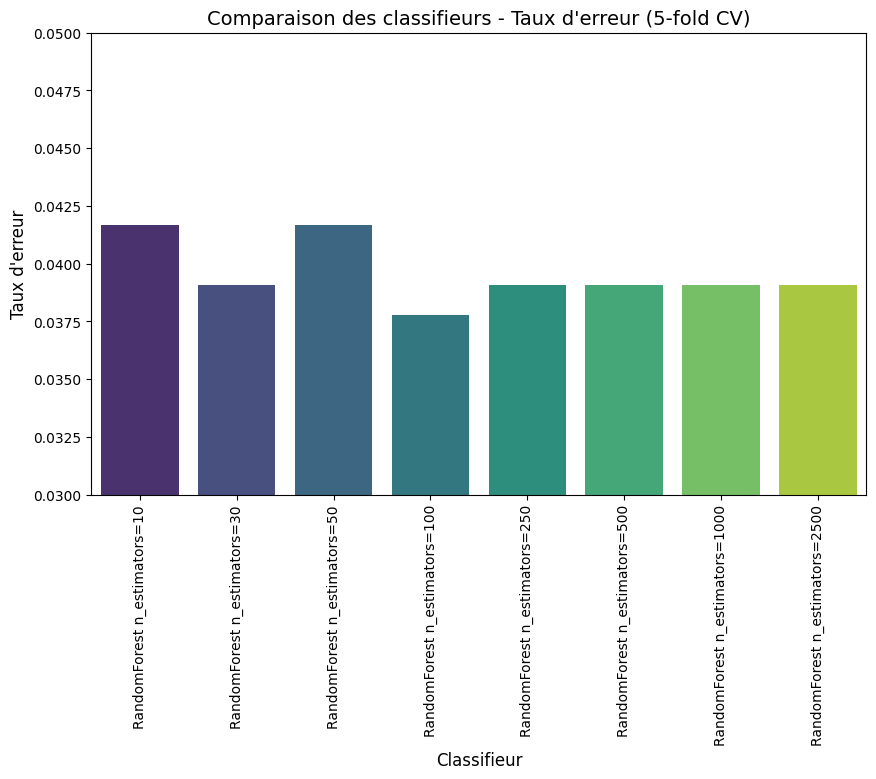

In [ ]:
#@title Affichage des résultats et choix du meilleur n_estimator pour une Random Forest
print(data_results)
min_risk = data_results["Taux d'erreur"].min()
best_classifier = data_results.loc[data_results["Taux d'erreur"] == min_risk, "Classifieur"].values[0]
print(f"Le meilleur classifieur est {best_classifier} avec un taux d'erreur de {min_risk:.3f}")


# Résultats en barplot
plt.figure(figsize=(10, 6))
sns.barplot(x="Classifieur", y="Taux d'erreur", data=data_results, palette="viridis")
plt.title("Comparaison des classifieurs - Taux d'erreur (5-fold CV)", fontsize=14)
plt.xlabel("Classifieur", fontsize=12)
plt.ylabel("Taux d'erreur", fontsize=12)
plt.xticks(rotation=90)
plt.ylim(0.03, 0.05)
plt.show()

In [ ]:
#@title Fitting n_estimator de Random Forest avec max_leaf_nodes = 10 par validation croisée
from sklearn.ensemble import RandomForestClassifier

X_col_names = data.drop(columns=['Classe_Y1', "Y1 : Charge_de_chauffage", "Classe_Y1"]).columns
y_col_name = 'Classe_Y1'

classifiers_to_test_n_leaf = {
    "RandomForest n_estimators=10": RandomForestClassifier(max_leaf_nodes = 10, n_estimators=10, random_state = 5),
    "RandomForest n_estimators=30": RandomForestClassifier(max_leaf_nodes = 10, n_estimators=30, random_state = 5),
    "RandomForest n_estimators=50": RandomForestClassifier(max_leaf_nodes = 10, n_estimators=50, random_state = 5),
    "RandomForest n_estimators=100": RandomForestClassifier(max_leaf_nodes = 10, n_estimators=100, random_state = 5),
    "RandomForest n_estimators=250": RandomForestClassifier(max_leaf_nodes = 10, n_estimators=250, random_state = 5),
    "RandomForest n_estimators=500": RandomForestClassifier(max_leaf_nodes = 10, n_estimators=500, random_state = 5),
    "RandomForest n_estimators=1000": RandomForestClassifier(max_leaf_nodes = 10, n_estimators=1000, random_state = 5),
    "RandomForest n_estimators=2500": RandomForestClassifier(max_leaf_nodes = 10, n_estimators=2500, random_state = 5),
}
X_col_names = data.drop(columns=[ "Y1 : Charge_de_chauffage", "Classe_Y1"]).columns
y_col_name = 'Classe_Y1'

data_results_n_leaf = pd.DataFrame(columns=["Classifieur", "Taux d'erreur"])
for classifier_name, classifier in classifiers_to_test_n_leaf.items():
    acc_mean = cross_validation(classifier, data, X_col_names, y_col_name, folds=5)
    risk_mean = 1 - acc_mean
    row = pd.DataFrame({"Classifieur": [classifier_name], "Taux d'erreur": [risk_mean]})
    data_results_n_leaf = pd.concat([data_results_n_leaf, row], ignore_index=True)



/tmp/ipython-input-970716114.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_results_n_leaf = pd.concat([data_results_n_leaf, row], ignore_index=True)


                      Classifieur  Taux d'erreur
0    RandomForest n_estimators=10       0.096350
1    RandomForest n_estimators=30       0.098998
2    RandomForest n_estimators=50       0.091181
3   RandomForest n_estimators=100       0.089874
4   RandomForest n_estimators=250       0.089882
5   RandomForest n_estimators=500       0.096401
6  RandomForest n_estimators=1000       0.097700
7  RandomForest n_estimators=2500       0.093770
Le meilleur classifieur est RandomForest n_estimators=100 avec un taux d'erreur de 0.090


/tmp/ipython-input-3010427507.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Classifieur", y="Taux d'erreur", data=data_results_n_leaf, palette="viridis")


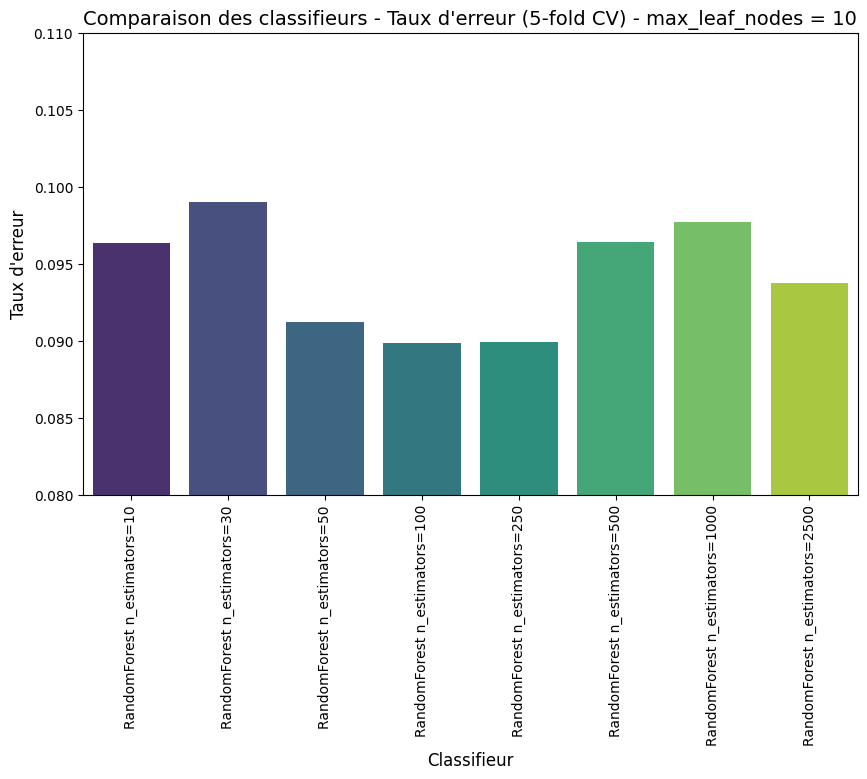

In [ ]:
#@title Affichage des résultats et choix du n_estimator pour une Random Forest avec max_leaf_nodes = 10
print(data_results_n_leaf)
min_risk_n_leaf = data_results_n_leaf["Taux d'erreur"].min()
best_classifier_n_leaf = data_results_n_leaf.loc[data_results_n_leaf["Taux d'erreur"] == min_risk_n_leaf, "Classifieur"].values[0]
print(f"Le meilleur classifieur est {best_classifier_n_leaf} avec un taux d'erreur de {min_risk_n_leaf:.3f}")


# Résultats en barplot
plt.figure(figsize=(10, 6))
sns.barplot(x="Classifieur", y="Taux d'erreur", data=data_results_n_leaf, palette="viridis")
plt.title("Comparaison des classifieurs - Taux d'erreur (5-fold CV) - max_leaf_nodes = 10", fontsize=14)
plt.xlabel("Classifieur", fontsize=12)
plt.ylabel("Taux d'erreur", fontsize=12)
plt.xticks(rotation=90)
plt.ylim(0.08, 0.11)
plt.show()

/!\ très dépendant du random state, chaque execution en changeant la base de train et la base de test change le n_estimator optimal. Il faut garder un n_estmator bas afin de réduire le nombre de claculs, sachant que le risque n'augmente pas de manière trop significative entre un n_estimator élevé et un n_estimator plus bas.

#Comparaison des modèles par validation croisée

In [ ]:

#@title Comparaison des modèles par validation croisée

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit

from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("==== COMPARAISON DES MODELES (validation croisée) ====")

# 1) Données complètes : X (features) et y (classe à prédire)
#  On part de Xdata (features) et de la variable cible Classe_Y1

X = Xdata.values                        # matrice numpy (n,d)
y = data["Classe_Y1"].values            # labels ('Class 1', ..., 'Class 4')


# 2) Définition des modèles à comparer

models = {
    "KNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=1)
    ),

    "Régression logistique": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            multi_class="multinomial",
            solver="lbfgs",
            max_iter=10000,
            random_state=0
        )
    ),

    "LDA": make_pipeline(
        StandardScaler(),
        LinearDiscriminantAnalysis()
    ),

    "QDA": make_pipeline(
        StandardScaler(),
        QuadraticDiscriminantAnalysis(reg_param=1e-3)
    ),

    "Perceptron": make_pipeline(
        StandardScaler(),
        Perceptron(
            max_iter=1000,
            eta0=1.0,
            random_state=0,
            penalty=None,
            fit_intercept=True
        )
    ),

    "Euclidien": make_pipeline(
        StandardScaler(),
        NearestCentroid(metric="euclidean")
    ),

    "Bayes naïf": GaussianNB(),

    "Arbre de décision": DecisionTreeClassifier(
        random_state=0,
    ),
    "Arbre de décision (min samples leaf)": DecisionTreeClassifier(
        random_state=0,
        min_samples_leaf=5
    ),
    "Arbre de décision (pruned)": DecisionTreeClassifier(
        random_state=0,
        ccp_alpha = 0.01
    ),

    "Random Forest": RandomForestClassifier( #gini par défaut
        n_estimators=100,
        random_state=5,
        n_jobs=-1
    ),
    "Random Forest (max_leaf_nodes=10)": RandomForestClassifier( #gini par défaut
        n_estimators=100,
        max_leaf_nodes=10,
        random_state=5,
        n_jobs=-1
    )
}


# 3) Validation croisée stratifiée


cv = StratifiedShuffleSplit(
    n_splits=100,   # nombre de tirages apprentissage/test
    test_size=0.2,
    random_state=42
)

# On stocke les risques (taux d'erreur) pour chaque modèle
risk_train = {name: [] for name in models.keys()}
risk_test  = {name: [] for name in models.keys()}

for train_idx, test_idx in cv.split(X, y):
    Xtr, Xte = X[train_idx], X[test_idx]
    ytr, yte = y[train_idx], y[test_idx]

    for name, model in models.items():
        # fit sur ce split
        model.fit(Xtr, ytr)

        # prédictions
        yhat_tr = model.predict(Xtr)
        yhat_te = model.predict(Xte)

        # taux d'erreur
        err_tr = np.mean(yhat_tr != ytr)
        err_te = np.mean(yhat_te != yte)

        risk_train[name].append(err_tr)
        risk_test[name].append(err_te)

# conversion en numpy arrays
for name in models.keys():
    risk_train[name] = np.array(risk_train[name])
    risk_test[name]  = np.array(risk_test[name])




/tmp/ipython-input-4033593701.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


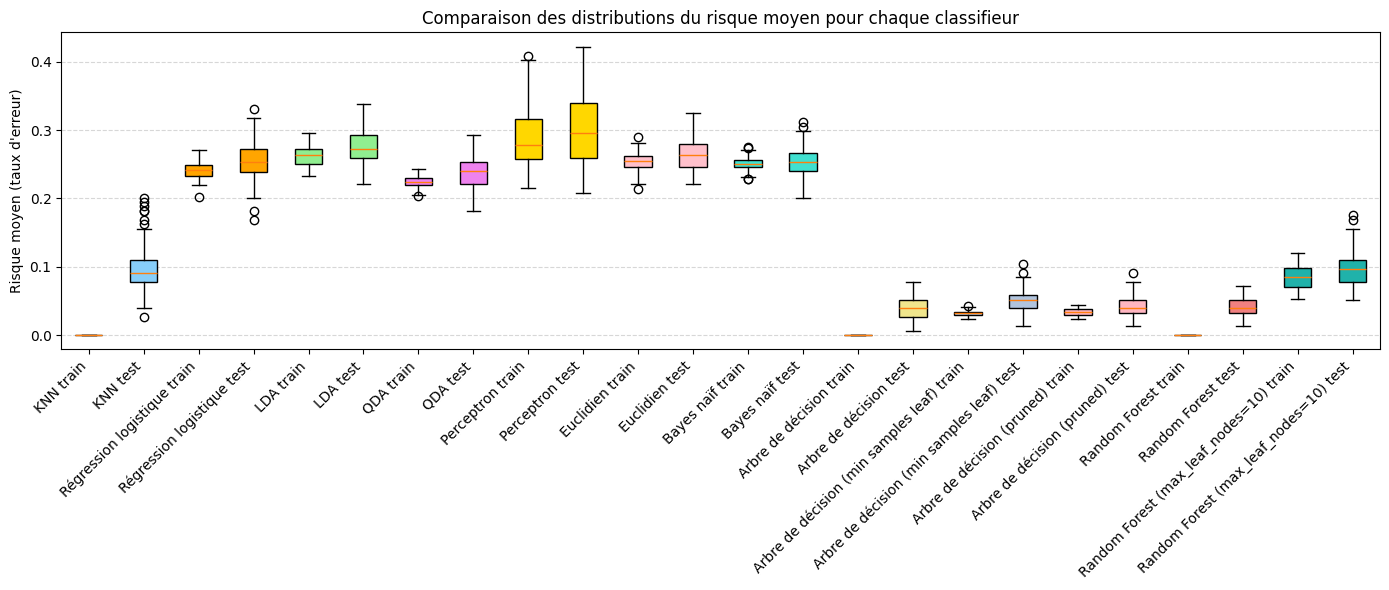

=== Moyenne des taux d'erreur (sur 100 splits) ===
KNN                   train : 0.000  test : 0.097
Régression logistique  train : 0.242  test : 0.255
LDA                   train : 0.263  test : 0.277
QDA                   train : 0.225  test : 0.237
Perceptron            train : 0.291  test : 0.302
Euclidien             train : 0.254  test : 0.262
Bayes naïf            train : 0.251  test : 0.254
Arbre de décision     train : 0.000  test : 0.040
Arbre de décision (min samples leaf)  train : 0.032  test : 0.051
Arbre de décision (pruned)  train : 0.034  test : 0.044
Random Forest         train : 0.000  test : 0.041
Random Forest (max_leaf_nodes=10)  train : 0.084  test : 0.098
Le meilleur classifieur est {'Arbre de décision'} avec un taux d'erreur moyen de 0.040


/tmp/ipython-input-4033593701.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Classifieur", y="Taux d'erreur", data=barplot_df, palette="viridis")


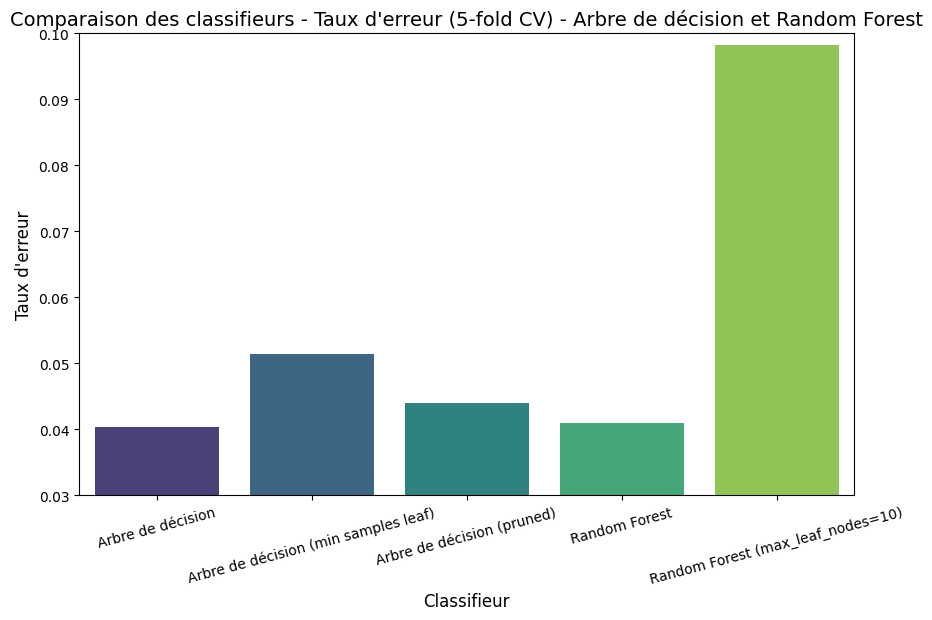

In [ ]:
# @title Boxplot comparatif (train/test)
import matplotlib.pyplot as plt
import pandas as pd

#Boxplot comparatif (train / test) avec couleurs

labels_box = []
data_box   = []
colors_box = []

color_map = {
    "KNN": "lightskyblue",
    "Régression logistique": "orange",
    "LDA": "lightgreen",
    "QDA": "violet",
    "Perceptron": "gold",
    "Euclidien": "pink",
    "Bayes naïf": "turquoise",
    "Arbre de décision": "khaki",
    "Arbre de décision (min samples leaf)": "lightsteelblue",
    "Arbre de décision (pruned)": "lightpink",
    "Random Forest": "lightcoral",
    "Random Forest (max_leaf_nodes=10)": "lightseagreen"
}

for name in models.keys():
    # distribution des risques train / test pour ce modèle
    data_box.append(risk_train[name])
    labels_box.append(f"{name} train")
    colors_box.append(color_map[name])

    data_box.append(risk_test[name])
    labels_box.append(f"{name} test")
    colors_box.append(color_map[name])

fig, ax = plt.subplots(figsize=(14, 6))

bp = ax.boxplot(
    data_box,
    labels=labels_box,
    patch_artist=True,
    showfliers=True
)

# appliquer les couleurs
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)

ax.set_ylabel("Risque moyen (taux d'erreur)")
ax.set_title("Comparaison des distributions du risque moyen pour chaque classifieur")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("=== Moyenne des taux d'erreur (sur 100 splits) ===")
mean_risks_data = []
for name in models.keys():
    print(
        f"{name:20s}  "
        f"train : {risk_train[name].mean():.3f}  "
        f"test : {risk_test[name].mean():.3f}"
    )
    mean_risks_data.append({'Classifieur': name, 'Taux d\'erreur': risk_test[name].mean()})

# Calculer la moyenne des risques pour chaque modèle
mean_risks = {name: val.mean() for name, val in risk_test.items()}

# Risque minimal
min_risk = min(mean_risks.values())

# Meilleur(s) classifieur(s)
best_classifier = {name for name, val in mean_risks.items() if val == min_risk}

# Affichage
print(f"Le meilleur classifieur est {best_classifier} avec un taux d'erreur moyen de {min_risk:.3f}")




# barplot
selected_models_for_barplot = [
    "Arbre de décision",
    "Arbre de décision (min samples leaf)",
    "Arbre de décision (pruned)",
    "Random Forest",
    "Random Forest (max_leaf_nodes=10)"
]

barplot_df = pd.DataFrame([item for item in mean_risks_data if item['Classifieur'] in selected_models_for_barplot])

plt.figure(figsize=(10, 6))
sns.barplot(x="Classifieur", y="Taux d'erreur", data=barplot_df, palette="viridis")
plt.title("Comparaison des classifieurs - Taux d'erreur (5-fold CV) - Arbre de décision et Random Forest", fontsize=14)
plt.xlabel("Classifieur", fontsize=12)
plt.ylabel("Taux d'erreur", fontsize=12)
plt.xticks(rotation=15)
plt.ylim(0.03, 0.1) # Adjusted ylim based on typical ranges for these models
plt.show()

# Analyse comparative des classifieurs

L’arbre de décision présente un taux d’erreur modéré, indiquant une capacité correcte à modéliser les données, mais une sensibilité possible aux variations de l’échantillon d’apprentissage. L’augmentation du nombre minimal d’échantillons par feuille entraîne une hausse du taux d’erreur, ce qui traduit une perte de précision liée à une contrainte trop forte du modèle.

L’arbre de décision élagué affiche un taux d’erreur plus faible que les autres variantes de l’arbre, montrant une meilleure généralisation et une réduction de la variance. Cette version permet de limiter le surapprentissage tout en conservant une structure de décision stable.

Le Random Forest obtient le taux d’erreur le plus bas parmi tous les modèles évalués, confirmant son efficacité et sa robustesse grâce à la combinaison de plusieurs arbres de décision. Ce modèle parvient à capter les relations complexes entre les variables tout en limitant le surapprentissage.

En revanche, le Random Forest avec un nombre maximal de feuilles limité présente le taux d’erreur le plus élevé. Cette contrainte excessive réduit la capacité du modèle à apprendre des structures pertinentes dans les données, ce qui dégrade significativement ses performances.

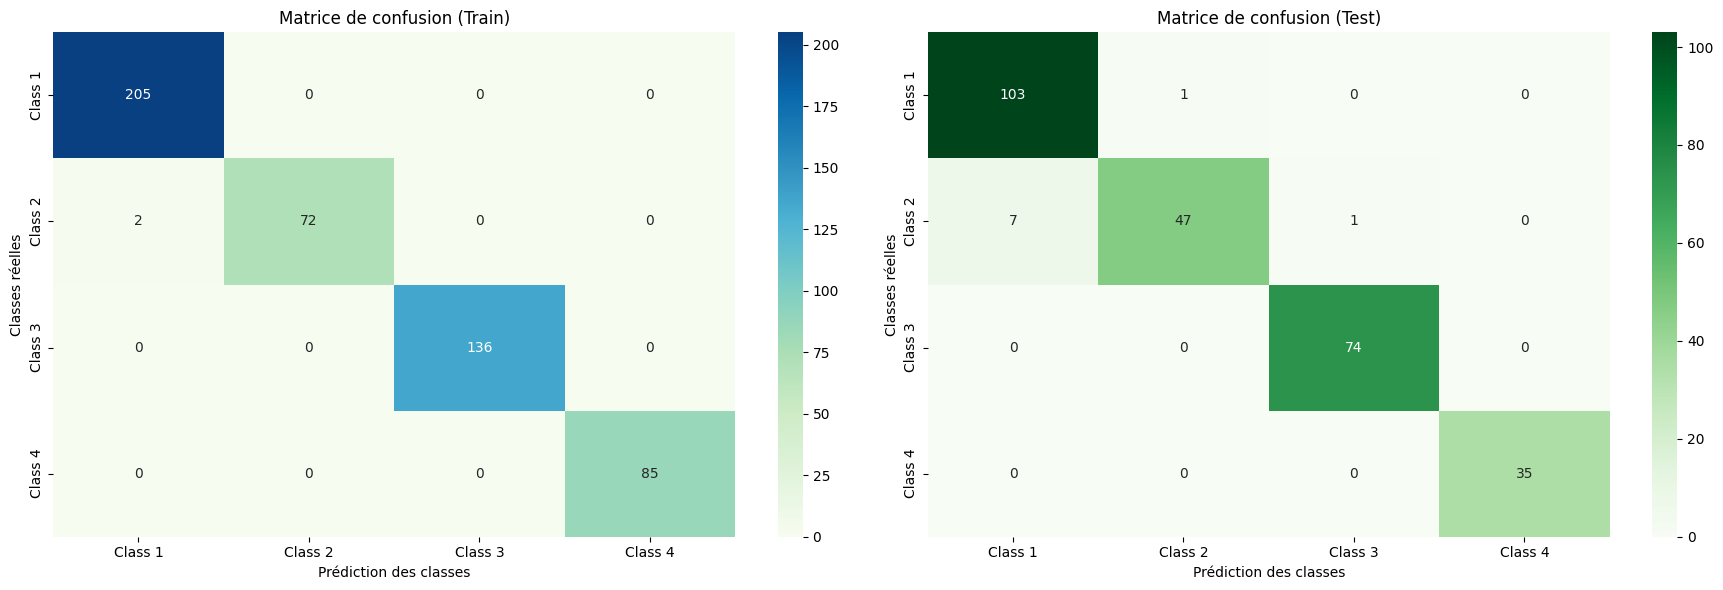

In [ ]:
# @title Matrices de confusions
from sklearn.metrics import confusion_matrix
import seaborn as sns

np.random.seed(407)
XTrain, XTest, YTrain, YTest = train_test_split(X, YR, train_size=500, random_state=407)
nTrain = XTrain.shape[0]
nTest = XTest.shape[0]

DT_base = DecisionTreeClassifier(random_state=0)
path = DT_base.cost_complexity_pruning_path(XTrain, YTrain)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

stock_accuracy_test = []
for ccp_alpha in ccp_alphas:
    DT_alpha_tmp = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    DT_alpha_tmp.fit(XTrain, YTrain)
    YhatTest_tmp = DT_alpha_tmp.predict(XTest)
    stock_accuracy_test.append(np.mean(YhatTest_tmp == YTest)) # Calculate accuracy for test set

optimal_ccp_alpha = ccp_alphas[np.argmax(stock_accuracy_test)]

# On définit et on entraine l'arbre de décision élagué
DT_elague = DecisionTreeClassifier(random_state=0, ccp_alpha=optimal_ccp_alpha)
DT_elague.fit(XTrain, YTrain)

# on prédit pour les classes de train et de test
YhatTrain = DT_elague.predict(XTrain)
YhatTest = DT_elague.predict(XTest)

# on génère les matrices de confusions
class_labels = np.unique(YTrain)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Matrice de confusion pour les échantillons train
cm_train = confusion_matrix(YTrain, YhatTrain)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='GnBu', ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels)
axes[0].set_title('Matrice de confusion (Train)')
axes[0].set_xlabel('Prédiction des classes')
axes[0].set_ylabel('Classes réelles')


# Matrice de confusion pour les échantillons test
cm_test = confusion_matrix(YTest, YhatTest)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=class_labels, yticklabels=class_labels)
axes[1].set_title('Matrice de confusion (Test)')
axes[1].set_xlabel('Prédiction des classes')
axes[1].set_ylabel('Classes réelles')

plt.tight_layout()
plt.savefig('confusion_matrices_DT_elague.png')
plt.show()

# Analyse des matrices de confusion

La matrice de confusion sur l’ensemble d’entraînement montre une classification quasi parfaite. Les classes 1, 3 et 4 sont entièrement correctement prédites, avec 100 % des observations situées sur la diagonale. La classe 2 présente seulement deux erreurs, confondue ponctuellement avec la classe 1, ce qui reste négligeable au regard du nombre total d’échantillons. Ces résultats indiquent une très forte capacité d’apprentissage du modèle sur les données d’entraînement.

Sur l’ensemble de test, les performances restent élevées, ce qui confirme une bonne capacité de généralisation. La classe 1 est très bien reconnue avec 103 prédictions correctes sur 104, tandis que la classe 3 et la classe 4 sont parfaitement classifiées, sans aucune erreur observée. La classe 2 est légèrement plus difficile à prédire, avec 47 prédictions correctes, et quelques confusions principalement vers la classe 1, ce qui suggère une proximité entre ces deux classes en termes de caractéristiques.

Globalement, la majorité des erreurs observées concernent des classes adjacentes en termes de performance énergétique, ce qui est cohérent d’un point de vue métier. L’écart limité entre les matrices d’entraînement et de test indique que le modèle ne présente pas de surapprentissage marqué et parvient à maintenir des performances stables sur des données non vues.

#Positionnement au regard de l’Ingénieurie Soutenable (IS) :

Afin de mesurer l'impact environnemental des classifieurs par le prisme de la consommation d'énergie, nous avons utilisé le module "codecarbon". Cela nous a permis de comparer les classifieurs entre eux d'un point de vu environnemental afin de nous aider à la sélection d'un classifieur à faible consommation. Nous prenons aussi en compte la possibilité du classifieur arbre de décision de nous fournir un plan "papier" nous évitant de générer à répétition le code lié. Ainsi, pour ce dernier classifieur, la consommation énergétique peut être amortie lorsque les tests sont multiples, nous pouvons donc le considérer comme soutenable.

Les objectifs IS sont aussi confirmés par l'objectif de notre projet, intrinsèquement lié à un objectif de soutenabilité, c'est à dire l'isolation et la charge de chauffage de logements. Ainsi, le projet en lui même rempli l'un des principaux objectifs IS tels que présentés par le label du même nom, en cherchant une solution en mobilisant le concept de sufficiency, c'est à dire en privilégiant la sobriété comme solution.

En effet, l'objectif du projet est double, adapter l'infrastructure de chauffage d'un logement en fonction de son architecture pour en optimiser la consommation d'énergie et privilégier une certaine forme d'architecture pour éviter les pertes énergétiques de futurs logements. Les critères étudiés, tels la surface, la répartition des fenêtres et l'orientation privilégient donc des solutions simples, presque Low-Tech. Ce principe est également confirmé par le choix d'un modèle qui, une fois réalisé peut permettre des tests à partir d'un plan papier.

Ainsi, le projet que nous avons accompli au cours de ce semestre cherche à tendre vers les objectifs du label Ingénierie Soutenable.


/tmp/ipython-input-1496079425.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


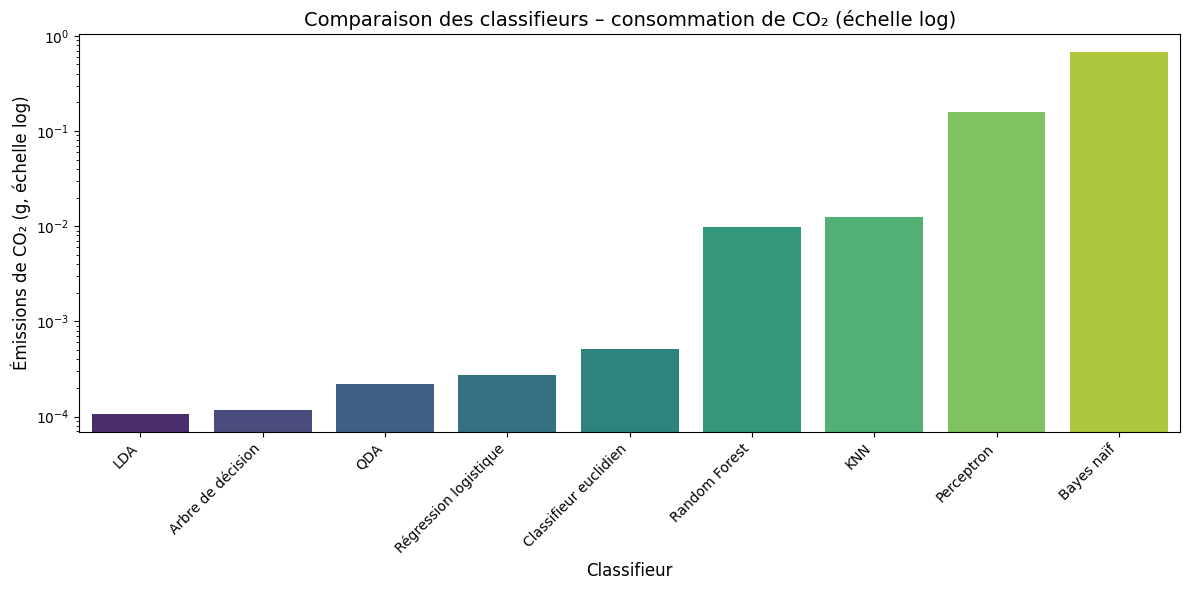

In [ ]:
# Comparaison des émissions CO2 des classifieurs

classifiers_to_test = {
    "Régression logistique": tracker_LR.final_emissions * 1000,
    "QDA": tracker_QDA.final_emissions * 1000,
    "LDA": tracker_LDA.final_emissions * 1000,
    "Perceptron": tracker_Perc.final_emissions * 1000,
    "KNN": tracker_KNN.final_emissions * 1000,
    "Classifieur euclidien": tracker_NC.final_emissions * 1000,
    "Bayes naïf": tracker_BN.final_emissions * 1000,
    "Arbre de décision": tracker_DT.final_emissions * 1000,
    "Random Forest": tracker_RF.final_emissions * 1000,
}

# --- Construction du DataFrame ---
carbone_results = pd.DataFrame(
    [
        {"Classifieur": name, "CO2 (g)": emission}
        for name, emission in classifiers_to_test.items()
    ]
)

# Tri
carbone_results = carbone_results.sort_values("CO2 (g)")

# --- Plot ---
plt.figure(figsize=(12, 6))
sns.barplot(
    x="Classifieur",
    y="CO2 (g)",
    data=carbone_results,
    palette="viridis"
)

plt.yscale("log")  # échelle logarithmique

plt.title("Comparaison des classifieurs – consommation de CO₂ (échelle log)", fontsize=14)
plt.xlabel("Classifieur", fontsize=12)
plt.ylabel("Émissions de CO₂ (g, échelle log)", fontsize=12)

# Rotation propre, lisible, pas trop longue
plt.xticks(rotation=45, ha="right", fontsize=10)

plt.tight_layout()
plt.show()


# Analyse de la comparaison des émissions CO2 des classifieurs

Les émissions de CO₂ varient fortement selon les classifieurs, avec des écarts de plusieurs ordres de grandeur.
Les modèles les plus simples, comme la LDA et l’arbre de décision, présentent les émissions les plus faibles, de l’ordre de 10⁻⁴ g de CO₂, traduisant un coût computationnel très limité.

La régression logistique, la QDA et le classifieur euclidien affichent des émissions légèrement supérieures, comprises entre 2×10⁻⁴ et 5×10⁻⁴ g, restant toutefois très faibles et comparables entre elles.

Le Random Forest montre une augmentation nette des émissions, autour de 10⁻² g de CO₂, soit environ 100 fois plus que les modèles linéaires ou simples, en raison de l’entraînement de multiples arbres. Le KNN présente un niveau similaire, légèrement supérieur, autour de 1,2×10⁻² g.

Le perceptron se situe encore plus haut, avec des émissions de l’ordre de 10⁻¹ g, tandis que le Bayes naïf apparaît comme le modèle le plus énergivore dans cette expérience, atteignant presque 1 g de CO₂, soit près de 10 000 fois plus que les modèles les moins coûteux.

Ces résultats confirment que la complexité algorithmique et le nombre de calculs nécessaires ont un impact majeur sur l’empreinte carbone des modèles de classification.

# Choix d'un modèle





En étudiant les graphiques issus de la validation croisée, nous constatons que le taux d’erreur moyen des classifieurs reste globalement inférieur à 30 %, ce qui confirme la présence d’une structure exploitable dans les données et une bonne capacité prédictive globale des modèles testés.

Cependant, tous les modèles ne se comportent pas de la même manière, que ce soit au niveau de leur taux d’erreur, de leur variance (robustesse) ou encore de leur niveau de surapprentissage.

Par exemple, le KNN, l’arbre de décision et le Random Forest apprennent presque parfaitement les données d’entraînement, mais leurs performances baissent en test. Cet écart indique un surapprentissage, plus ou moins marqué selon les modèles. Le KNN, notamment, surapprend fortement et reste assez instable selon les splits.

Le Perceptron, lui, obtient de mauvais résultats et présente une forte variance, ce qui en fait un modèle peu fiable.

À l’inverse, les modèles linéaires comme la régression logistique, LDA, QDA, le classifieur euclidien ou encore le Bayes naïf montrent un comportement plus stable : leurs erreurs en train et en test sont proches. Cependant, leurs performances restent limitées, avec des taux d’erreur autour de 23–27 %. Cela montre qu’ils n’arrivent pas suffisamment à séparer les différentes classes de notre base.

Pour conclure, les meilleures performances sont obtenues par le KNN, l’arbre de décision et le Random Forest, qui se situent autour de 10 % d’erreur en moyenne. Le modèle que nous avons retenu est l’arbre de décision, car il propose selon nous le meilleur compromis. Il est performant, plus stable que le KNN et le Random Forest, beaucoup plus simple à interpréter, et consomme nettement moins d’énergie que le Random Forest. Enfin, même si l’on observe un petit surapprentissage, celui-ci reste raisonnable.

C’est donc l’arbre de décision que nous retenons à l'issu de notre projet.



# Analyse critique et pistes d’amélioration

Malgré les bons résultats obtenus, notre projet présente plusieurs limites qui ouvrent la voie à des améliorations. Notamment :

**1. Limites liées à la discrétisation de la variable cible**

La charge de chauffage est initialement une variable continue, qui a été discrétisée en quatre classes de largeur égale. Ce choix introduit une perte d’information. Deux bâtiments proches en termes de charge réelle peuvent se retrouver dans des classes différentes si une frontière est franchie.

Pistes d’amélioration :

Comparer cette approche de classification à une approche de régression (régression linéaire, Lasso).

Tester d’autres méthodes de discrétisation, par exemple basées sur les quantiles ou sur des seuils issus de normes énergétiques réelles.

**2. Taille et nature de la base de données**

La base de données utilisée contient 768 observations, ce qui est relativement modeste au regard des méthodes de Machine Learning modernes. De plus, les bâtiments sont issus de simulations et non de mesures réelles, ce qui peut limiter la généralisation des résultats à des cas concrets.

Pistes d’amélioration :

Tester la robustesse des modèles via une validation croisée plus exhaustive (k-fold stratifié).

Appliquer les modèles à d’autres bases de données énergétiques, incluant des bâtiments réels.

**3. Intégration de l’ingénierie soutenable**

L’analyse de l’empreinte carbone des algorithmes reste exploratoire et dépend fortement du matériel utilisé et du temps d’exécution.

Pistes d’amélioration :

Réaliser des comparaisons normalisées de la consommation énergétique par itération ou par observation.

Étudier l’impact du choix des hyperparamètres sur la consommation carbone.

**Conclusion critique**

En définitive, ce projet montre que le Machine Learning constitue un outil pertinent pour l’évaluation rapide de la performance énergétique des bâtiments, mais que son efficacité dépend fortement des choix méthodologiques effectués en amont. Une amélioration future du modèle passerait par une meilleure exploitation de la variable cible continue, un enrichissement des données et une prise en compte plus systématique des enjeux de soutenabilité. Ces perspectives ouvrent la voie à des outils d’aide à la conception plus performants, plus responsables et mieux adaptés aux enjeux actuels de la transition énergétique.

#Conclusion

L’objectif de ce projet était d’étudier dans quelle mesure des algorithmes de Machine Learning permettent de prédire le niveau de charge de chauffage d’un bâtiment à partir de caractéristiques architecturales et géométriques simples, dans un contexte de transition énergétique et d’ingénierie soutenable. La problématique posée : **Comment prédire le niveau de charge de chauffage d’un bâtiment à partir de ses caractéristiques architecturales et géométriques**; a été abordée à travers une approche de classification, après discrétisation de la charge de chauffage en plusieurs niveaux de performance énergétique.

Pour répondre à cette problématique, plusieurs classifieurs ont été implémentés et comparés. Les meilleurs résultats en termes de précision ont été obtenus par le Random Forest, l’arbre de décision et le KNN, ce dernier se révélant toutefois plus sensible au choix des hyperparamètres et moins robuste face aux variations de la base de test.

Parmi ces modèles, l’arbre de décision élagué a finalement été retenu comme modèle de référence. Il offre en effet le meilleur compromis entre précision, capacité de généralisation, interprétabilité des résultats et impact carbone limité. Contrairement à des méthodes plus complexes comme le Random Forest, l’arbre de décision permet une lecture directe des règles de décision, ce qui constitue un atout majeur dans un contexte applicatif lié à l’ingénierie du bâtiment, où la compréhension des facteurs influençant la performance énergétique est essentielle. De plus, son coût de calcul relativement faible en fait un modèle cohérent avec les objectifs de sobriété numérique et de réduction de l’empreinte environnementale des algorithmes.

D’un point de vue d’ingénierie soutenable, l’arbre de décision se distingue ainsi comme l’un des modèles les moins énergivores parmi ceux testés, tout en conservant un niveau de performance élevé. À l’inverse, des approches plus sophistiquées, telles que les méthodes d’ensemble, bien qu’efficaces en termes d’accuracy, présentent un surcoût computationnel qui n’est pas toujours justifié par le gain de performance observé. L’étude pourrait néanmoins être améliorée en optimisant plus finement les hyperparamètres des modèles, en explorant des variantes plus légères d’ensembles de classifieurs ou encore en enrichissant la base de données afin de faciliter la séparation entre les classes énergétiques.

Dans l’ensemble, l’objectif fixé a été atteint : un modèle de classification fiable, robuste et cohérent avec les contraintes du projet a pu être sélectionné. Ce travail met en évidence que des modèles de Machine Learning relativement simples, appliqués à des variables facilement accessibles, constituent des outils pertinents pour l’évaluation rapide de la performance énergétique des bâtiments, en complément des méthodes de calcul traditionnelles. Il ouvre ainsi des perspectives intéressantes pour l’aide à la décision en phase de conception architecturale, tout en intégrant les enjeux actuels de durabilité et de sobriété numérique.


In [ ]:
# @title Conversion du notebook en fichier HTML
# Upload ipynb
from google.colab import files
f = files.upload()

# Convert ipynb to html
import subprocess
file0 = list(f.keys())[0]
_ = subprocess.run(["pip", "install", "nbconvert"])
_ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])

# download the html
files.download(file0[:-5]+"html")

Saving Projet ML01_ to Projet ML01_


FileNotFoundError: Cannot find file: Projet html

# Bibliographie

https://www.kaggle.com/code/abu2208/starter-energy-efficiency-dataset-94ba86c0-6

https://www.kaggle.com/code/tohidyousefi/predicting-the-energy-efficiency-of-buildings
